In [10]:
import pandas as pd
import copy
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
from nltk.corpus import stopwords
import re
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer



In [13]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: False
GPU: No GPU


**Data Load**

In [14]:
train = pd.read_csv('Training_data_9.csv')
test= pd.read_csv('Test_data.csv')
print(train.shape)
train.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Training_data_9.csv'

In [4]:
test.head()

,News Headline,News Topic
0,<html> <body> <br> <br> News Headlines:\n <b>...,Science and Technology
1,<html> <body> <br> <br> News Headlines:\n <b>...,Science and Technology
2,<html> <body> <br> <br> News Headlines:\n <b>...,World News
3,<html> <body> <br> <br> News Headlines:\n <b>...,Business
4,<html> <body> <br> <br> News Headlines:\n <b>...,Business


In [5]:
print("Shape of dataset:", train.shape)
print("\nMissing values:\n", train.isnull().sum())
print("\nDuplicate rows:", train.duplicated().sum())

Shape of dataset: (88829, 2)

Missing values:
 News Headline    0
News Topic       0
dtype: int64

Duplicate rows: 28833


**Class Distribution**

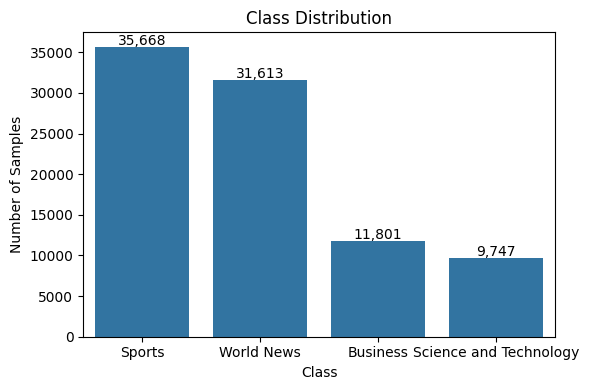

In [6]:
# Count class distribution
class_counts = train['News Topic'].value_counts()
# Plot
plt.figure(figsize=(6,4))
ax = sns.barplot(x=class_counts.index, y=class_counts.values)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

for i, value in enumerate(class_counts.values):
    ax.text(i, value + 200, f"{value:,}", ha='center')

plt.tight_layout()
plt.show()

**Word Count Analysis**


Word Count Stats:
 count    88829.000000
mean        47.080357
std          9.808124
min         17.000000
25%         41.000000
50%         47.000000
75%         52.000000
max        179.000000
Name: word_count, dtype: float64


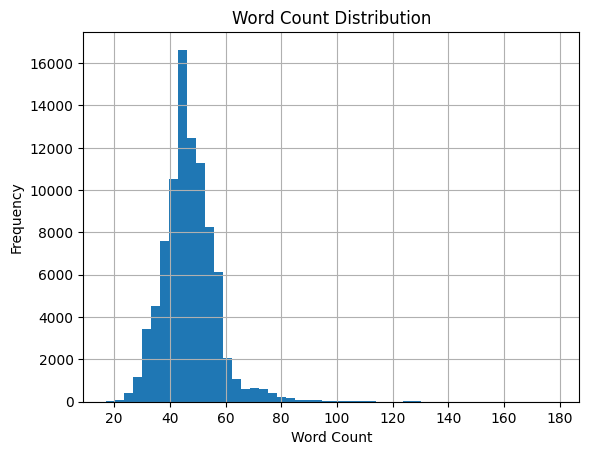

In [7]:
# 2. Word Count
# -------------------------
train['word_count'] = train['News Headline'].str.split().str.len()

print("\nWord Count Stats:\n", train['word_count'].describe())

plt.figure()
train['word_count'].hist(bins=50)
plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()


News Topic
Business                  46.568087
Science and Technology    46.250744
Sports                    46.710917
World News                47.944200
Name: word_count, dtype: float64


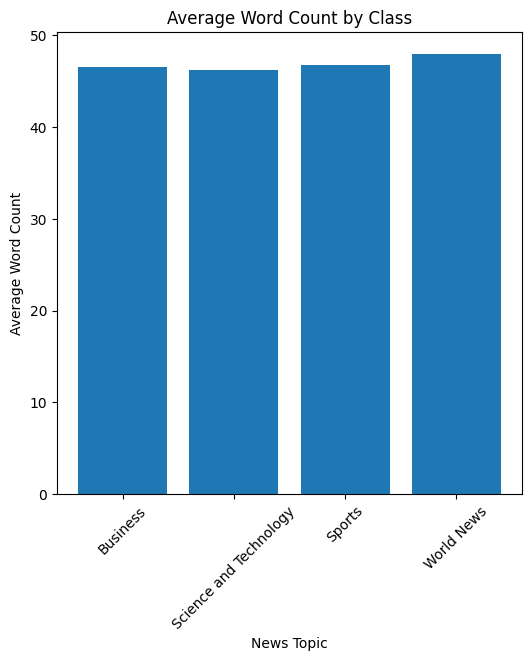

In [8]:
# Average word count by class
avg_wc = train.groupby('News Topic')['word_count'].mean()
print(avg_wc)
plt.figure(figsize=(6,6))  # square plot

plt.bar(avg_wc.index, avg_wc.values)

plt.title("Average Word Count by Class")
plt.xlabel("News Topic")
plt.ylabel("Average Word Count")

plt.xticks(rotation=45)

plt.show()

In [9]:
# 3. HTML Detection
# -------------------------
train['has_html'] = train['News Headline'].str.contains(r'<.*?>', regex=True)

print("\nHTML Presence:\n", train['has_html'].value_counts())

html_percent = train['has_html'].mean() * 100
print(f"\nHTML %: {html_percent:.2f}%")
# 4. Remove HTML
# -------------------------
train['clean_text'] = train['News Headline'].str.replace(r'<.*?>', '', regex=True)



HTML Presence:
 has_html
True    88829
Name: count, dtype: int64

HTML %: 100.00%


In [10]:
train['text_length'] = train['clean_text'].apply(len)
print(train['text_length'])

0        264
1        192
2        267
3        220
4        168
        ... 
88824    274
88825    221
88826    271
88827    264
88828    212
Name: text_length, Length: 88829, dtype: int64



Word count stats:(after HTML strip )
count    88829.000000
mean        40.080357
std          9.808124
min         10.000000
25%         34.000000
50%         40.000000
75%         45.000000
max        172.000000
Name: word_count, dtype: float64


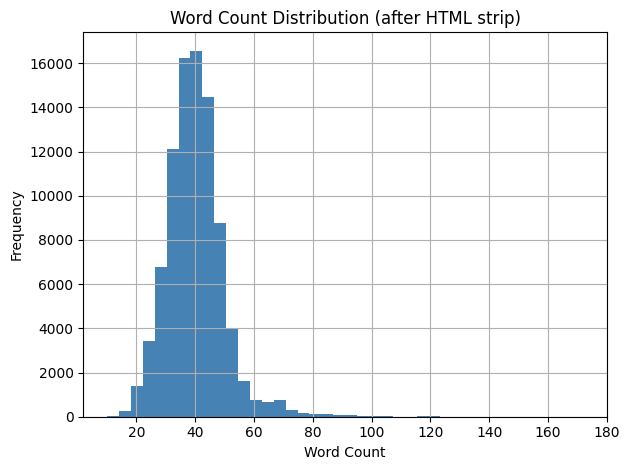


Avg word count by class:
News Topic
Business                  39.6
Science and Technology    39.3
Sports                    39.7
World News                40.9
Name: word_count, dtype: float64


In [11]:
train["word_count"] = train['clean_text'].str.split().str.len()

print("\nWord count stats:(after HTML strip )")
print(train["word_count"].describe())

train["word_count"].hist(bins=40, color="steelblue")
plt.title("Word Count Distribution (after HTML strip)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("word_count_distribution.png")
plt.show()


print("\nAvg word count by class:")
print(train.groupby("News Topic")["word_count"].mean().round(1))

**Word Frequency Analysis**

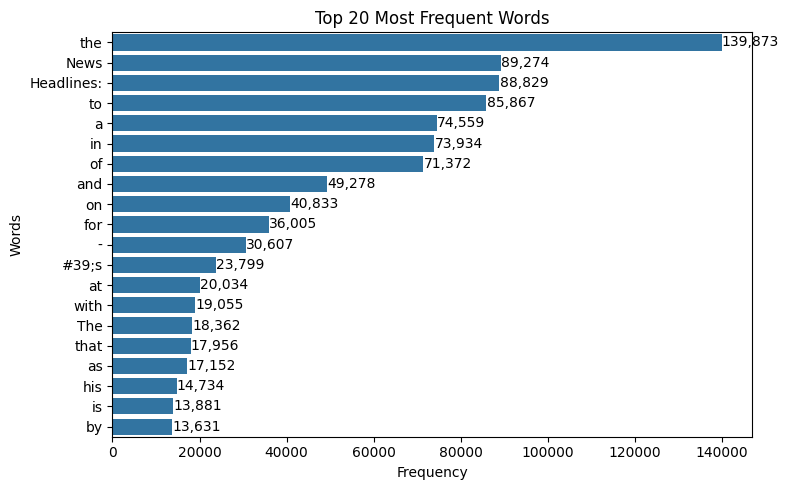

In [12]:
from collections import Counter

all_words = " ".join(train['clean_text']).split()
word_counts=Counter(all_words).most_common(20)
# Separate words and counts
words, counts = zip(*word_counts)

# Plot
plt.figure(figsize=(8,5))
ax=sns.barplot(x=list(counts), y=list(words))
for i, v in enumerate(counts):
    ax.text(v + 50, i, f"{v:,}", va='center')
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.tight_layout()
plt.show()

In [13]:
train['News Topic'].value_counts()

News Topic
Sports                    35668
World News                31613
Business                  11801
Science and Technology     9747
Name: count, dtype: int64

In [14]:
train['text_length'] = train['clean_text'].apply(len)
print(train['text_length'])

0        264
1        192
2        267
3        220
4        168
        ... 
88824    274
88825    221
88826    271
88827    264
88828    212
Name: text_length, Length: 88829, dtype: int64


**Word Cloud**

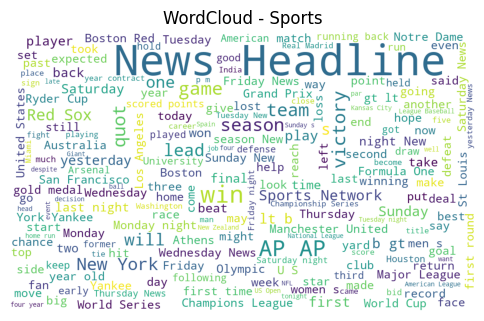

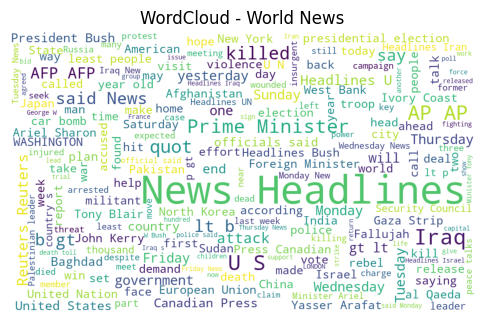

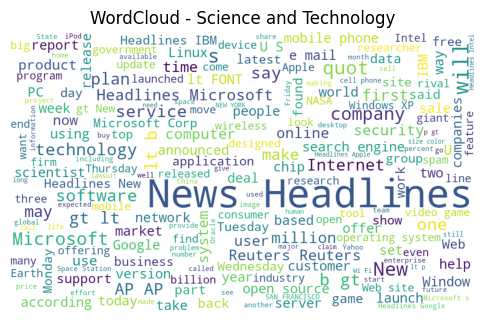

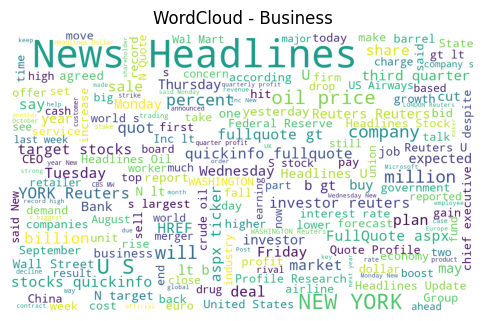

In [15]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Loop through each class
for label in train['News Topic'].unique():

    # Get text for that class
    text = " ".join(train[train['News Topic'] == label]['clean_text'])

    # Generate word cloud
    wc = WordCloud(width=1000, height=600, background_color='white')
    cloud = wc.generate(text)

    # Plot
    plt.figure(figsize=(6,6))
    plt.imshow(cloud)
    plt.title(f"WordCloud - {label}")
    plt.axis('off')
    plt.show()

**Stopwords Analysis**

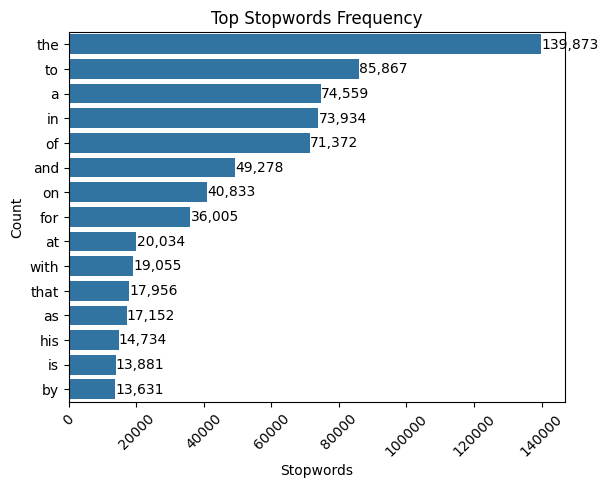

In [16]:


stop_words = set(stopwords.words('english'))

def plot_stopwords(texts):
    words = " ".join(texts).split()

    stopword_list = [w for w in words if w in stop_words]
    freq = Counter(stopword_list).most_common(15)

    words, counts = zip(*freq)

    plt.figure()
    #plt.bar(words, counts)
    ax=sns.barplot(x=list(counts), y=list(words))
    for i, v in enumerate(counts):
       ax.text(v + 50, i, f"{v:,}", va='center')
    plt.xticks(rotation=45)
    plt.title("Top Stopwords Frequency")
    plt.xlabel("Stopwords")
    plt.ylabel("Count")
    plt.show()

plot_stopwords(train['News Headline'])

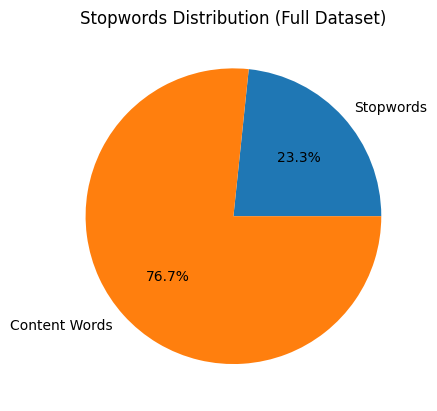

In [17]:
def stopword_pie_full(texts):
    total_words = 0
    stop_words_count = 0

    for t in texts:
        words = t.split()
        total_words += len(words)
        stop_words_count += sum(1 for w in words if w in stop_words)

    non_stop = total_words - stop_words_count

    plt.figure()
    plt.pie([stop_words_count, non_stop],
            labels=["Stopwords", "Content Words"],
            autopct='%1.1f%%')
    plt.title("Stopwords Distribution (Full Dataset)")
    plt.show()

stopword_pie_full(train['News Headline'])

The analysis shows that stopwords constitute approximately 23.3% of the total words in the dataset.

Although they do not dominate the dataset, their presence is still significant and contributes to noise, as they do not carry meaningful semantic information for classification tasks.
Therefore, stopwords are removed in extreme preprocessing to improve model efficiency. 

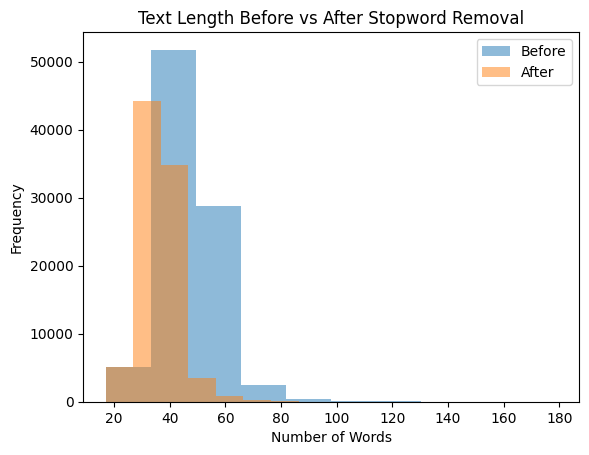

In [18]:
def compare_stopwords(texts):
    before = []
    after = []

    for t in texts:
        words = t.split()
        before.append(len(words))
        after.append(len([w for w in words if w not in stop_words]))

    plt.figure()
    plt.hist(before, alpha=0.5, label='Before')
    plt.hist(after, alpha=0.5, label='After')
    plt.legend()
    plt.title("Text Length Before vs After Stopword Removal")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.show()

compare_stopwords( train['News Headline'])

In [19]:

# ==================== FIX: Download stopwords ====================
nltk.download('stopwords', quiet=True)   # quiet=True hides the download message

stop_words = stopwords.words('english')

# Your existing code
clean_for_eda = train['News Headline'].copy()   # better to use .copy()

# Remove HTML tags
clean_for_eda = clean_for_eda.str.replace(r"<.*?>", " ", regex=True)

print("\nTop words per class (stopwords removed, HTML stripped):")

for topic in train["News Topic"].unique():
    # Combine all headlines for this topic
    texts = " ".join(clean_for_eda[train["News Topic"] == topic].tolist()).lower()

    # Extract words with 3 or more letters
    words = re.findall(r"\b[a-z]{3,}\b", texts)

    # Remove stopwords
    filtered = [w for w in words if w not in stop_words]

    # Get top 10 most common words
    top_10 = Counter(filtered).most_common(10)

    print(f"\n  {topic}: {top_10}")


Top words per class (stopwords removed, HTML stripped):

  Sports: [('news', 36153), ('headlines', 35719), ('game', 5284), ('first', 5144), ('new', 4958), ('season', 4204), ('win', 4195), ('team', 4172), ('two', 3991), ('one', 3830)]

  World News: [('news', 32397), ('headlines', 31626), ('said', 8171), ('iraq', 6232), ('reuters', 5721), ('president', 4473), ('two', 3793), ('new', 3760), ('minister', 3555), ('afp', 3546)]

  Science and Technology: [('news', 10192), ('headlines', 9756), ('new', 2339), ('microsoft', 1642), ('software', 1178), ('said', 1177), ('reuters', 1122), ('internet', 1088), ('company', 954), ('space', 905)]

  Business: [('news', 12255), ('headlines', 11806), ('reuters', 3358), ('said', 2925), ('new', 2641), ('oil', 2545), ('stocks', 1730), ('prices', 1730), ('inc', 1722), ('company', 1656)]


In [20]:
def top_words(texts):
    return Counter(" ".join(texts).split()).most_common(20)

print("Class Sports:", top_words(train[train['News Topic']=='Sports']['clean_text']))
print("Class World News:", top_words(train[train['News Topic']=='World News']['clean_text']))

Class Sports: [('the', 66537), ('News', 35771), ('Headlines:', 35668), ('to', 32174), ('a', 29286), ('in', 27463), ('of', 23639), ('and', 18154), ('for', 15603), ('on', 14191), ('#39;s', 11315), ('at', 10838), ('-', 10321), ('his', 9046), ('with', 8971), ('The', 7786), ('as', 6280), ('was', 6248), ('is', 5249), ('that', 4917)]
Class World News: [('the', 45068), ('in', 32654), ('to', 32216), ('News', 31812), ('Headlines:', 31613), ('of', 30410), ('a', 28373), ('and', 18571), ('on', 16569), ('-', 14235), ('for', 11822), ('that', 7129), ('#39;s', 6997), ('as', 6274), ('at', 6208), ('with', 6063), ('The', 6040), ('said', 5818), ('by', 5475), ('an', 5179)]


# **Preprocessing**

 ***1- no preprocess***

In [21]:
X_train_no = train['News Headline']
X_test_no=test['News Headline']

 ***2- extreme***

In [22]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def extreme_preprocess(text):
    # Remove HTML
    text = re.sub(r'<.*?>', ' ', text)

    # Lowercase
    text = text.lower()

    # Remove encoding artifacts
    text = re.sub(r'#39;s', '', text)

    # Remove non-letters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Tokenize
    words = text.split()

    # Remove stopwords first
    words = [w for w in words if w not in stop_words]

    # Remove dataset-specific noise
    words = [w for w in words if w not in ['news','headlines']]

    # Apply stemming
    words = [stemmer.stem(w) for w in words]

    # Join
    text = " ".join(words)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

train['text_extreme'] = train['News Headline'].apply(extreme_preprocess)
test['text_extreme'] = test['News Headline'].apply(extreme_preprocess)

 ***3- optimum***

In [23]:
def optimum_preprocess(text):
    text = re.sub(r'<.*?>', ' ', text)
    text = text.lower()
    text = re.sub(r'#39;', "'", text)

    # controlled cleaning (not too aggressive)
    text = re.sub(r'[^a-z\s]', ' ', text)

    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [w for w in words if w not in ['news','headlines']]

    return " ".join(words)
train['text_optimum'] = train['News Headline'].apply(optimum_preprocess)
test['text_optimum'] = test['News Headline'].apply(optimum_preprocess)

In [24]:
import pandas as pd
import numpy as np

def get_stats(texts):
    total_words = 0
    vocab = set()
    lengths = []

    for t in texts:
        words = t.split()
        total_words += len(words)
        vocab.update(words)
        lengths.append(len(words))

    return {
        "Avg Length": np.mean(lengths),
        "Max Length": np.max(lengths),
        "Min Length": np.min(lengths),
        "Total Words": total_words,
        "Vocab Size": len(vocab)
    }

# Generate stats
raw_stats = get_stats( train['News Headline'])
extreme_stats = get_stats(train['text_extreme'])
optimum_stats = get_stats( train['text_optimum'])

# Create DataFrame
comparison_df = pd.DataFrame([raw_stats, extreme_stats, optimum_stats],
                             index=["Raw", "Extreme", "Optimum"])

comparison_df

,Avg Length,Max Length,Min Length,Total Words,Vocab Size
Raw,47.080357,179,17,4182101,128088
Extreme,25.546725,131,6,2269290,33122
Optimum,25.546736,131,6,2269291,47959


# **Traing data split**

In [25]:
from sklearn.model_selection import train_test_split

X = train['News Headline']
y = train['News Topic']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train_raw = X_train
X_val_raw = X_val
############
X_train_ex = X_train.apply(extreme_preprocess)
X_val_ex = X_val.apply(extreme_preprocess)
#######
X_train_op = X_train.apply(optimum_preprocess)
X_val_op = X_val.apply(optimum_preprocess)

In [26]:
print(len(X_train_raw), len(X_train_ex), len(X_train_op))
print(len(X_val_raw), len(X_val_ex), len(X_val_op))

71063 71063 71063
17766 17766 17766


# **Tf**-IDF

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ========================= RAW (No Preprocessing) =========================
tfidf_raw = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True,
    stop_words='english'
)

X_train_raw_tfidf = tfidf_raw.fit_transform(X_train_raw)   # ← dataset passed here
X_val_raw_tfidf   = tfidf_raw.transform(X_val_raw)

# ========================= EXTREME Preprocessing =========================
tfidf_ex = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True,
    stop_words=None
)

X_train_ex_tfidf = tfidf_ex.fit_transform(X_train_ex)
X_val_ex_tfidf   = tfidf_ex.transform(X_val_ex)

# ========================= OPTIMUM Preprocessing =========================
tfidf_op = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True,
    stop_words=None
)

X_train_op_tfidf = tfidf_op.fit_transform(X_train_op)
X_val_op_tfidf   = tfidf_op.transform(X_val_op)

print("TF-IDF Completed!")
print('For training')
print("Raw    → Train:", X_train_raw_tfidf.shape, "Val:", X_val_raw_tfidf.shape)
print("Extreme→ Train:", X_train_ex_tfidf.shape,  "Val:", X_val_ex_tfidf.shape)
print("Optimum→ Train:", X_train_op_tfidf.shape,  "Val:", X_val_op_tfidf.shape)
print('For testing')
# Test
X_test_raw_tfidf = tfidf_raw.transform(test['News Headline'])          
X_test_op_tfidf  = tfidf_op.transform(test['text_optimum'])            
X_test_ex_tfidf  = tfidf_ex.transform(test['text_extreme'])    
print("Raw    → Test:", X_test_raw_tfidf.shape)
print("Extreme→ Test:", X_test_ex_tfidf.shape)
print("Optimum→ Test:", X_test_op_tfidf.shape)       

TF-IDF Completed!
For training
Raw    → Train: (71063, 20000) Val: (17766, 20000)
Extreme→ Train: (71063, 20000) Val: (17766, 20000)
Optimum→ Train: (71063, 20000) Val: (17766, 20000)
For testing
Raw    → Test: (12000, 20000)
Extreme→ Test: (12000, 20000)
Optimum→ Test: (12000, 20000)


#SkipGram

In [28]:
####### Do not run it again.
# !pip install gensim
import gensim.downloader as api
import numpy as np
from tqdm import tqdm
import time

print("Downloading pre-trained Skip-gram Word2Vec model (Google News 300d)...")
print("This may take 1–2 minutes the first time.")

start = time.time()
wv = api.load("word2vec-google-news-300")   # ← This is the pre-trained Skip-gram model
print(f"Model loaded! Vector size = {wv.vector_size} | Time taken: {time.time()-start:.1f} seconds")

This may take 1–2 minutes the first time.
Model loaded! Vector size = 300 | Time taken: 19.3 seconds


In [29]:
def get_document_vector(text, model=wv, dim=300):
    """Average word vectors for a single headline. Handles OOV words gracefully."""
    if not isinstance(text, str) or text.strip() == "":
        return np.zeros(dim)

    words = text.split()                                      # already space-separated
    vectors = [model[word] for word in words if word in model]

    if len(vectors) == 0:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

In [30]:
print("Converting all 3 versions to Skip-gram embeddings...")

# ====================== RAW (No Preprocessing) ======================
X_train_raw_sg = np.array([get_document_vector(text) for text in tqdm(X_train_raw, desc="Raw Train")])
X_val_raw_sg   = np.array([get_document_vector(text) for text in tqdm(X_val_raw,   desc="Raw Val")])

# ====================== EXTREME Preprocessing ======================
X_train_ex_sg = np.array([get_document_vector(text) for text in tqdm(X_train_ex, desc="Extreme Train")])
X_val_ex_sg   = np.array([get_document_vector(text) for text in tqdm(X_val_ex,   desc="Extreme Val")])

# ====================== OPTIMUM Preprocessing ======================
X_train_op_sg = np.array([get_document_vector(text) for text in tqdm(X_train_op, desc="Optimum Train")])
X_val_op_sg   = np.array([get_document_vector(text) for text in tqdm(X_val_op,   desc="Optimum Val")])

print("\nSkip-gram embeddings created successfully!")
print(f"Raw    → Train: {X_train_raw_sg.shape} | Val: {X_val_raw_sg.shape}")
print(f"Extreme→ Train: {X_train_ex_sg.shape}  | Val: {X_val_ex_sg.shape}")
print(f"Optimum→ Train: {X_train_op_sg.shape}  | Val: {X_val_op_sg.shape}")

Converting all 3 versions to Skip-gram embeddings...


Optimum Val: 100%|██████████| 17766/17766 [00:00<00:00, 36392.89it/s]


Skip-gram embeddings created successfully!
Raw    → Train: (71063, 300) | Val: (17766, 300)
Extreme→ Train: (71063, 300)  | Val: (17766, 300)
Optimum→ Train: (71063, 300)  | Val: (17766, 300)


In [31]:
from matplotlib import cm
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Logistic Regression

In [32]:
def train_ml_model(X_train, X_val, y_train, y_val, name):
    print(f"\n{'='*60}")
    print(f"Training Logistic Regression → {name}")
    print(f"{'='*60}")

    model = LogisticRegression(
        max_iter=1000,
        random_state=42,
        solver='lbfgs',
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_val)

    # Metrics
    acc = accuracy_score(y_val, y_pred)
    f1_macro = f1_score(y_val, y_pred, average='macro')
    cm = confusion_matrix(y_val, y_pred)
    print(f"Accuracy   : {acc:.4f}")
    print(f"Macro F1   : {f1_macro:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, digits=4))
    print("\nConfusion Matrix:")
    print(cm)

    # Save model
    joblib.dump(model, f'lr_{name.lower().replace(" ", "_")}.pkl')
    print(f"Model saved as: lr_{name.lower().replace(' ', '_')}.pkl")

    return model, acc, f1_macro

# ========================= RUN ON ALL 6 FEATURE SETS =========================

results = []

# 1. TF-IDF - Raw
logregTFIDFraw, acc1, f11 = train_ml_model(X_train_raw_tfidf, X_val_raw_tfidf, y_train, y_val, "TF-IDF Raw")

# 2. TF-IDF - Extreme
logregTFIDFextreme, acc2, f12 = train_ml_model(X_train_ex_tfidf,  X_val_ex_tfidf,  y_train, y_val, "TF-IDF Extreme")

# 3. TF-IDF - Optimum
logregTFIDFoptimum, acc3, f13 = train_ml_model(X_train_op_tfidf,  X_val_op_tfidf,  y_train, y_val, "TF-IDF Optimum")


Training Logistic Regression → TF-IDF Raw


f:\CSE440\dl_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy   : 0.9384
Macro F1   : 0.9113

Classification Report:
                        precision    recall  f1-score   support

              Business     0.8890    0.8381    0.8628      2360
Science and Technology     0.8773    0.8440    0.8604      1949
                Sports     0.9652    0.9912    0.9780      7134
            World News     0.9427    0.9453    0.9440      6323

              accuracy                         0.9384     17766
             macro avg     0.9186    0.9047    0.9113     17766
          weighted avg     0.9374    0.9384    0.9377     17766


Confusion Matrix:
[[1978  169   40  173]
 [ 116 1645   47  141]
 [  11    3 7071   49]
 [ 120   58  168 5977]]
Model saved as: lr_tf-idf_raw.pkl

Training Logistic Regression → TF-IDF Extreme


f:\CSE440\dl_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy   : 0.9371
Macro F1   : 0.9100

Classification Report:
                        precision    recall  f1-score   support

              Business     0.8776    0.8475    0.8623      2360
Science and Technology     0.8790    0.8384    0.8582      1949
                Sports     0.9635    0.9913    0.9772      7134
            World News     0.9451    0.9399    0.9425      6323

              accuracy                         0.9371     17766
             macro avg     0.9163    0.9043    0.9100     17766
          weighted avg     0.9363    0.9371    0.9365     17766


Confusion Matrix:
[[2000  157   45  158]
 [ 131 1634   45  139]
 [  11    3 7072   48]
 [ 137   65  178 5943]]
Model saved as: lr_tf-idf_extreme.pkl

Training Logistic Regression → TF-IDF Optimum


f:\CSE440\dl_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Accuracy   : 0.9373
Macro F1   : 0.9103

Classification Report:
                        precision    recall  f1-score   support

              Business     0.8841    0.8369    0.8598      2360
Science and Technology     0.8779    0.8450    0.8612      1949
                Sports     0.9626    0.9912    0.9767      7134
            World News     0.9444    0.9424    0.9434      6323

              accuracy                         0.9373     17766
             macro avg     0.9172    0.9039    0.9103     17766
          weighted avg     0.9364    0.9373    0.9366     17766


Confusion Matrix:
[[1975  167   53  165]
 [ 121 1647   44  137]
 [  11    3 7071   49]
 [ 127   59  178 5959]]
Model saved as: lr_tf-idf_optimum.pkl


The hyperparameter max_iter=1000 was chosen to ensure convergence during training. Text data with high dimensionality often requires more iterations for the optimization algorithm to converge; lower values (e.g., 100 or 200) resulted in incomplete convergence warnings and suboptimal performance during initial experiments.

The solver='lbfgs' was selected because it is well-suited for multiclass classification problems and performs efficiently on medium-to-large datasets. It supports multinomial loss optimization, which aligns with the multi-class nature of the classification task. Alternative solvers such as liblinear were not preferred due to slower performance and limitations in handling larger datasets.

The n_jobs=-1 parameter enables parallel computation using all available CPU cores, reducing training time significantly without affecting model performance.

In [33]:
from torchinfo import summary

def print_model_summary(model, input_size=(64, 35, 300), device='cuda'):
    """
    Prints detailed model summary with input/output shapes
    """
    model = model.to(device)
    print(f"{'='*80}")
    print(f"Model Summary - {model.__class__.__name__}")
    print(f"{'='*80}")
    
    summary(model, 
            input_size=input_size, 
            device=device,
            col_names=["input_size", "output_size", "num_params"],
            depth=4)
    
    print(f"{'='*80}\n")

# **Deep Neural Network (TF-idf)**

In [34]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

print("PyTorch imports ready")

PyTorch imports ready


In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_val   = le.transform(y_val)

num_classes = len(np.unique(y_train))
print(f"Number of classes: {num_classes}")

Number of classes: 4


In [36]:
print(X_train_raw_tfidf.shape, y_train.shape)
print(X_val_raw_tfidf.shape, y_val.shape)

(71063, 20000) (71063,)
(17766, 20000) (17766,)


In [37]:
print("Train classes:", np.unique(y_train))
print("Val classes:", np.unique(y_val))

Train classes: [0 1 2 3]
Val classes: [0 1 2 3]


In [38]:
# ========================= PyTorch DNN TRAINING FUNCTION =========================
def train_dnn_model(X_train, X_val, y_train, y_val, name, epochs=10, batch_size=32):
    print(f"\n{'='*60}")
    print(f"Training DNN (PyTorch) → {name}")
    print(f"{'='*60}")

    # Convert to PyTorch tensors
    X_train_t = torch.tensor(X_train.toarray(), dtype=torch.float32) if hasattr(X_train, 'toarray') else torch.tensor(X_train, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val.toarray(),   dtype=torch.float32) if hasattr(X_val, 'toarray')   else torch.tensor(X_val, dtype=torch.float32)
    
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_val_t   = torch.tensor(y_val,   dtype=torch.long)

    # Create DataLoaders
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset   = TensorDataset(X_val_t, y_val_t)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

    # Define the model (same architecture as before)
    class DNN(nn.Module):
        def __init__(self, input_dim, num_classes):
            super().__init__()
            self.model = nn.Sequential(
                nn.Linear(input_dim, 256),
                nn.ReLU(),
                nn.Dropout(0.4),
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Linear(64, num_classes)
            )
        
        def forward(self, x):
            return self.model(x)

    model = DNN(X_train_t.shape[1], num_classes)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training loop
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()




        y_true, y_pred = [], []
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(device)
                outputs = model(batch_x)
                preds = torch.argmax(outputs, dim=1)
                y_true.extend(batch_y.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())
        
        acc = accuracy_score(y_true, y_pred)
        f1_macro = f1_score(y_true, y_pred, average='macro')
        cm = confusion_matrix(y_true, y_pred)
   
        
        print(f"Epoch {epoch+1}/{epochs} - Val Accuracy: {acc:.4f} - Val Macro F1: {f1_macro:.4f}")
    

    # Final evaluation
    print(f"\nFinal Results for {name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1 Macro : {f1_macro:.4f}")
    print(classification_report(y_true, y_pred))
    print("\nConfusion Matrix:")
    print(cm)
    

    return model, acc, f1_macro


In [39]:
# Train on all three TF-IDF versions

# RAW
dnn1_Raw, acc1, f11 = train_dnn_model(
    X_train_raw_tfidf, X_val_raw_tfidf,
    y_train, y_val,
    "DNN TF-IDF Raw"
)

# EXTREME
dnn2_Extreme, acc2, f12 = train_dnn_model(
    X_train_ex_tfidf, X_val_ex_tfidf,
    y_train, y_val,
    "DNN TF-IDF Extreme"
)

# OPTIMAL
dnn3_Optimal, acc3, f13 = train_dnn_model(
    X_train_op_tfidf, X_val_op_tfidf,
    y_train, y_val,
    "DNN TF-IDF Optimal"
)


Training DNN (PyTorch) → DNN TF-IDF Raw
Epoch 1/10 - Val Accuracy: 0.9419 - Val Macro F1: 0.9157
Epoch 2/10 - Val Accuracy: 0.9460 - Val Macro F1: 0.9168
Epoch 3/10 - Val Accuracy: 0.9425 - Val Macro F1: 0.9095
Epoch 4/10 - Val Accuracy: 0.9464 - Val Macro F1: 0.9157
Epoch 5/10 - Val Accuracy: 0.9443 - Val Macro F1: 0.9115
Epoch 6/10 - Val Accuracy: 0.9438 - Val Macro F1: 0.9116
Epoch 7/10 - Val Accuracy: 0.9451 - Val Macro F1: 0.9127
Epoch 8/10 - Val Accuracy: 0.9431 - Val Macro F1: 0.9106
Epoch 9/10 - Val Accuracy: 0.9456 - Val Macro F1: 0.9139
Epoch 10/10 - Val Accuracy: 0.9450 - Val Macro F1: 0.9138

Final Results for DNN TF-IDF Raw
Accuracy : 0.9450
F1 Macro : 0.9138
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      2360
           1       0.84      0.85      0.85      1949
           2       0.99      0.98      0.99      7134
           3       0.95      0.97      0.96      6323

    accuracy                           0.95   

A Deep Neural Network was used to capture non-linear patterns from high-dimensional TF-IDF features. The architecture (256 → 128 → 64) was designed to first capture rich feature interactions and then gradually reduce dimensionality to avoid overfitting.

The first layer uses 256 neurons to handle the high dimensionality of TF-IDF features. Since the input space is very large and sparse, a higher number of neurons helps the model capture more feature interactions in the early stage. Using a smaller size (e.g., 64 or 128) may lead to loss of important information, while much larger sizes increase computational cost and risk of overfitting. Therefore, 256 provides a good balance between learning capacity and generalization.

For optimization, the Adam optimizer with a learning rate of 0.001 was used. Adam is generally reliable and converges faster for this type of problem. A higher learning rate made training unstable, while a lower one slowed down learning too much, so 0.001 worked best.

A Dropout rate of 0.4 was introduced after the first layer to reduce overfitting. Since TF-IDF vectors are sparse and high-dimensional, the model can easily memorize patterns. A relatively higher dropout (0.4 instead of 0.2–0.3) was empirically chosen to improve generalization performance based on validation results.

# sequence skip-gram for further code

In [40]:
import numpy as np
from tqdm import tqdm
import gc

MAX_LEN = 35
EMBEDDING_DIM = 300

print(f"Generating sequences: (samples, {MAX_LEN}, {EMBEDDING_DIM})")

Generating sequences: (samples, 35, 300)


# **(Skip-gram for sequence)**

In [41]:
import numpy as np
from tqdm import tqdm
import gc

MAX_LEN = 35
EMBEDDING_DIM = 300

print(f"Generating sequences: (samples, {MAX_LEN}, {EMBEDDING_DIM})")

Generating sequences: (samples, 35, 300)


In [42]:
def text_to_sequence(text, wv, max_len=MAX_LEN):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return np.zeros((max_len, EMBEDDING_DIM), dtype=np.float32)
    
    words = text.split()
    seq = np.zeros((max_len, EMBEDDING_DIM), dtype=np.float32)
    
    for i, word in enumerate(words[:max_len]):
        if word in wv:
            seq[i] = wv[word]
    
    return seq

In [43]:
print("🚀 Starting Skip-gram Sequence Generation for All 3 Versions...\n")

# ========================= RAW =========================
print("Processing RAW...")
X_train_raw_seq = np.array([text_to_sequence(text, wv) for text in tqdm(X_train_raw, desc="Raw Train")])
X_val_raw_seq   = np.array([text_to_sequence(text, wv) for text in tqdm(X_val_raw,   desc="Raw Val")])

# ========================= EXTREME =========================
print("\nProcessing EXTREME...")
X_train_ex_seq = np.array([text_to_sequence(text, wv) for text in tqdm(X_train_ex, desc="Extreme Train")])
X_val_ex_seq   = np.array([text_to_sequence(text, wv) for text in tqdm(X_val_ex,   desc="Extreme Val")])

# ========================= OPTIMUM =========================
print("\nProcessing OPTIMUM...")
X_train_op_seq = np.array([text_to_sequence(text, wv) for text in tqdm(X_train_op, desc="Optimum Train")])
X_val_op_seq   = np.array([text_to_sequence(text, wv) for text in tqdm(X_val_op,   desc="Optimum Val")])

print("\nSkip-gram Sequence Generation for training Completed!")
print(f"Raw     → Train: {X_train_raw_seq.shape} | Val: {X_val_raw_seq.shape}")
print(f"Extreme → Train: {X_train_ex_seq.shape} | Val: {X_val_ex_seq.shape}")
print(f"Optimum → Train: {X_train_op_seq.shape} | Val: {X_val_op_seq.shape}")

gc.collect()

🚀 Starting Skip-gram Sequence Generation for All 3 Versions...

Processing RAW...


Raw Val: 100%|██████████| 17766/17766 [00:00<00:00, 26716.14it/s]



Processing EXTREME...


Extreme Val: 100%|██████████| 17766/17766 [00:00<00:00, 30523.67it/s]



Processing OPTIMUM...


Optimum Val: 100%|██████████| 17766/17766 [00:00<00:00, 28741.14it/s]



Skip-gram Sequence Generation for training Completed!
Raw     → Train: (71063, 35, 300) | Val: (17766, 35, 300)
Extreme → Train: (71063, 35, 300) | Val: (17766, 35, 300)
Optimum → Train: (71063, 35, 300) | Val: (17766, 35, 300)


8204

In [44]:
# Generate sequences using the same function
X_test_raw_seq = np.array([text_to_sequence(text, wv) for text in tqdm(test['News Headline'], desc="Test Raw")])

X_test_op_seq = np.array([text_to_sequence(text, wv) for text in tqdm(test['text_optimum'], desc="Test Optimum")])

X_test_ex_seq = np.array([text_to_sequence(text, wv) for text in tqdm(test['text_extreme'], desc="Test Extreme")])
print("\n✅ Skip-gram Sequence Generation for testing Completed!")
print(f"Raw     → Test: {X_test_raw_seq.shape}")
print(f"Extreme → Test: {X_test_ex_seq.shape}")
print(f"Optimum → Test: {X_test_op_seq.shape}")

gc.collect()

Test Extreme: 100%|██████████| 12000/12000 [00:00<00:00, 30648.77it/s]



✅ Skip-gram Sequence Generation for testing Completed!
Raw     → Test: (12000, 35, 300)
Extreme → Test: (12000, 35, 300)
Optimum → Test: (12000, 35, 300)


9

In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize
import gc
import torch.optim as optim

from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight


# **Bi-directional RNN**

In [46]:
# ========================= OPTIMIZED Bi RNN MODEL =========================
class OptimizedBiRNN(nn.Module):
    def __init__(self, input_size=300, hidden_size=256, num_layers=2,
                 num_classes=4, dropout=0.3, bidirectional=True):
        super().__init__()

        self.num_directions = 2 if bidirectional else 1

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0
        )

        # TensorFlow-style Dense layers
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * self.num_directions, 256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )
        self.layer_norm = nn.LayerNorm(hidden_size * self.num_directions)

        # Reduced dropout (more stable)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        rnn_out, _ = self.rnn(x)

        # Combine mean + max pooling (important improvement)
        mean_pool = torch.mean(rnn_out, dim=1)
        max_pool, _ = torch.max(rnn_out, dim=1)

        out = mean_pool + max_pool   # feature fusion

        out = self.layer_norm(out)
        out = self.dropout(out)

        out = self.fc(out)

        return out
Bi_Rnn = OptimizedBiRNN()
summary(Bi_Rnn, 
        input_size=(64, 35, 300), 
        device='cuda' if torch.cuda.is_available() else 'cpu',
        col_names=["input_size", "output_size", "num_params", "trainable"],
        depth=4)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
OptimizedBiRNN                           [64, 35, 300]             [64, 4]                   --                        True
├─RNN: 1-1                               [64, 35, 300]             [64, 35, 512]             679,936                   True
├─LayerNorm: 1-2                         [64, 512]                 [64, 512]                 1,024                     True
├─Dropout: 1-3                           [64, 512]                 [64, 512]                 --                        --
├─Sequential: 1-4                        [64, 512]                 [64, 4]                   --                        True
│    └─Linear: 2-1                       [64, 512]                 [64, 256]                 131,328                   True
│    └─ReLU: 2-2                         [64, 256]                 [64, 256]                 --                        --
│    └─

In [47]:
def train_optimized_BiRNN(X_train_seq, X_val_seq, y_train, y_val, name,
                          epochs=15, batch_size=64, patience=4):

    print(f"\n{'='*75}")
    print(f"Training Optimized BiRNN → {name}")
    print(f"{'='*75}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ---------------- CLASS WEIGHTS (FIX FOR IMBALANCE) ----------------
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight='balanced',
                                   classes=classes,
                                   y=y_train)
    class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

    # ---------------- DATA ----------------
    X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val_seq, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_val_t   = torch.tensor(y_val, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                              batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),
                              batch_size=batch_size, shuffle=False)

    # ---------------- MODEL ----------------
    Bi_Rnn = OptimizedBiRNN().to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(Bi_Rnn.parameters(), lr=0.0003, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)


    # ---------------- EARLY STOPPING ----------------
    best_val_f1 = 0.0
    patience_counter = 0
    best_biRNN = None
    best_preds = None
    min_delta = 1e-4

    train_losses, val_losses = [], []
    val_accs, val_f1s = [], []

    for epoch in range(epochs):

        # -------- TRAIN --------
        Bi_Rnn.train()
        train_loss = 0.0

        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = Bi_Rnn(batch_x)
            loss = criterion(outputs, batch_y)

            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(Bi_Rnn.parameters(), 5)

            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # -------- VALIDATION --------
        Bi_Rnn.eval()
        y_true, y_pred = [], []
        val_loss = 0.0

        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)

                outputs = Bi_Rnn(batch_x)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)

                y_true.extend(batch_y.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        val_loss /= len(val_loader)

        acc = accuracy_score(y_true, y_pred)
        f1_macro = f1_score(y_true, y_pred, average='macro')

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(acc)
        val_f1s.append(f1_macro)

        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Acc: {acc:.4f} | F1: {f1_macro:.4f}")

        # -------- EARLY STOPPING --------
        if f1_macro > best_val_f1 + min_delta:
            best_val_f1 = f1_macro
            best_biRNN = copy.deepcopy(Bi_Rnn.state_dict())
            best_preds = (y_true.copy(), y_pred.copy())
            patience_counter = 0
        else:
            patience_counter += 1

       

        if patience_counter >= patience:
            print(f"\n Early stopping at epoch {epoch+1}")
            break

    # -------- LOAD BEST MODEL --------
  
    if best_biRNN is not None:
        Bi_Rnn.load_state_dict(best_biRNN)   

    # -------- SAFE BEST PREDS --------
    if best_preds is None:
        print("⚠ No improvement detected, using last epoch results")
        best_preds = (y_true, y_pred)

    y_true, y_pred = best_preds

    # -------- FINAL RESULTS --------
    print(f"\n Final Results - {name}")
  

    

    final_acc = accuracy_score(y_true, y_pred)
    final_f1  = f1_score(y_true, y_pred, average='macro')

    print(f"Final Accuracy : {final_acc:.4f}")
    print(f"Final Macro F1 : {final_f1:.4f}")

    print("\n Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    print("\n Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    # -------- PLOTS --------
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.plot(train_losses)
    plt.plot(val_losses)
    plt.title("Loss")

    plt.subplot(1,3,2)
    plt.plot(val_accs)
    plt.title("Accuracy")

    plt.subplot(1,3,3)
    plt.plot(val_f1s)
    plt.title("Macro F1")

    plt.show()

    return Bi_Rnn, best_val_f1


Training Optimized BiRNN → BiRNN - Raw Skip-gram


f:\CSE440\dl_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  1/15 | Train Loss: 0.3091 | Val Loss: 0.2284 | Acc: 0.9223 | F1: 0.8899
Epoch  2/15 | Train Loss: 0.2175 | Val Loss: 0.2060 | Acc: 0.9272 | F1: 0.8945
Epoch  3/15 | Train Loss: 0.1919 | Val Loss: 0.1917 | Acc: 0.9327 | F1: 0.9013
Epoch  4/15 | Train Loss: 0.1744 | Val Loss: 0.1891 | Acc: 0.9351 | F1: 0.9043
Epoch  5/15 | Train Loss: 0.1594 | Val Loss: 0.1711 | Acc: 0.9407 | F1: 0.9112
Epoch  6/15 | Train Loss: 0.1452 | Val Loss: 0.1733 | Acc: 0.9435 | F1: 0.9150
Epoch  7/15 | Train Loss: 0.1354 | Val Loss: 0.1699 | Acc: 0.9451 | F1: 0.9151
Epoch  8/15 | Train Loss: 0.1271 | Val Loss: 0.1711 | Acc: 0.9451 | F1: 0.9149
Epoch  9/15 | Train Loss: 0.1206 | Val Loss: 0.1710 | Acc: 0.9423 | F1: 0.9110
Epoch 10/15 | Train Loss: 0.1158 | Val Loss: 0.1681 | Acc: 0.9473 | F1: 0.9169
Epoch 11/15 | Train Loss: 0.1112 | Val Loss: 0.1635 | Acc: 0.9468 | F1: 0.9171
Epoch 12/15 | Train Loss: 0.1055 | Val Loss: 0.1614 | Acc: 0.9487 | F1: 0.9188
Epoch 13/15 | Train Loss: 0.1025 | Val Loss: 0.1669 

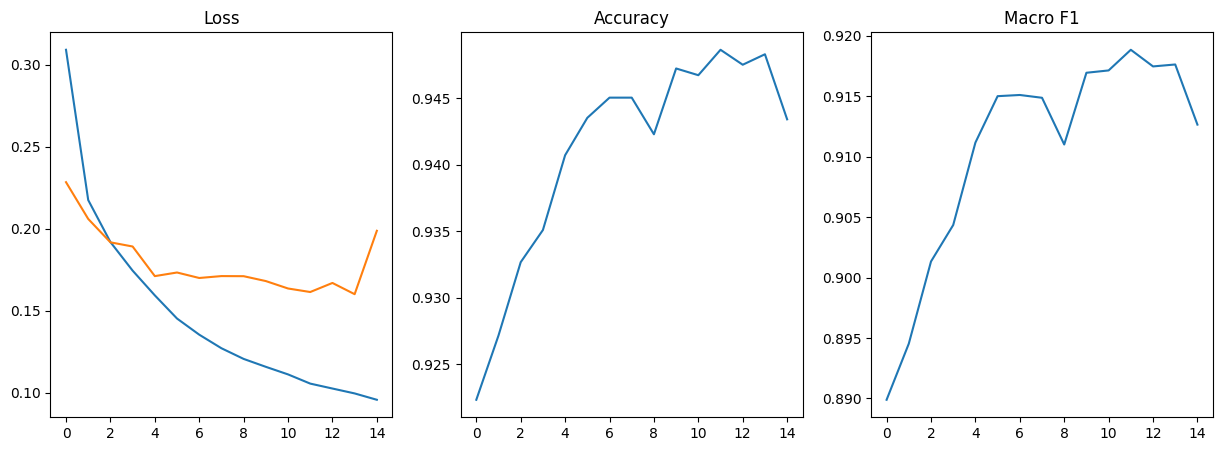

In [48]:
# Train Optimized BiRNN on RAW Skip-gram
BiRNN_raw, best_f1_raw = train_optimized_BiRNN(
    X_train_raw_seq, 
    X_val_raw_seq, 
    y_train, 
    y_val, 
    name="BiRNN - Raw Skip-gram"
)


Training Optimized BiRNN → BiRNN - Extreme Skip-gram


f:\CSE440\dl_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  1/15 | Train Loss: 0.3754 | Val Loss: 0.2867 | Acc: 0.9051 | F1: 0.8683
Epoch  2/15 | Train Loss: 0.2713 | Val Loss: 0.2558 | Acc: 0.9131 | F1: 0.8792
Epoch  3/15 | Train Loss: 0.2437 | Val Loss: 0.2537 | Acc: 0.9157 | F1: 0.8801
Epoch  4/15 | Train Loss: 0.2206 | Val Loss: 0.2263 | Acc: 0.9259 | F1: 0.8950
Epoch  5/15 | Train Loss: 0.2043 | Val Loss: 0.2266 | Acc: 0.9268 | F1: 0.8953
Epoch  6/15 | Train Loss: 0.1913 | Val Loss: 0.2176 | Acc: 0.9278 | F1: 0.8961
Epoch  7/15 | Train Loss: 0.1772 | Val Loss: 0.2107 | Acc: 0.9293 | F1: 0.8965
Epoch  8/15 | Train Loss: 0.1656 | Val Loss: 0.2236 | Acc: 0.9299 | F1: 0.8979
Epoch  9/15 | Train Loss: 0.1569 | Val Loss: 0.2246 | Acc: 0.9286 | F1: 0.8940
Epoch 10/15 | Train Loss: 0.1507 | Val Loss: 0.2151 | Acc: 0.9337 | F1: 0.9015
Epoch 11/15 | Train Loss: 0.1400 | Val Loss: 0.2046 | Acc: 0.9359 | F1: 0.9041
Epoch 12/15 | Train Loss: 0.1345 | Val Loss: 0.2151 | Acc: 0.9366 | F1: 0.9038
Epoch 13/15 | Train Loss: 0.1320 | Val Loss: 0.2127 

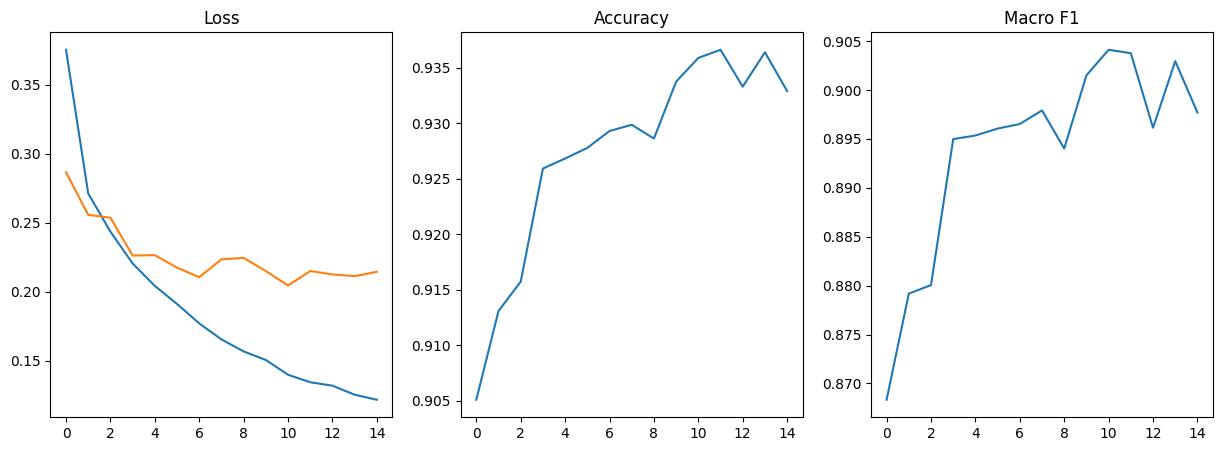


Training Optimized BiRNN → BiRNN - Optimum Skip-gram


f:\CSE440\dl_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  1/15 | Train Loss: 0.3226 | Val Loss: 0.2295 | Acc: 0.9209 | F1: 0.8893
Epoch  2/15 | Train Loss: 0.2297 | Val Loss: 0.2082 | Acc: 0.9275 | F1: 0.8968
Epoch  3/15 | Train Loss: 0.2013 | Val Loss: 0.1949 | Acc: 0.9324 | F1: 0.9029
Epoch  4/15 | Train Loss: 0.1825 | Val Loss: 0.1884 | Acc: 0.9353 | F1: 0.9063
Epoch  5/15 | Train Loss: 0.1647 | Val Loss: 0.1751 | Acc: 0.9386 | F1: 0.9106
Epoch  6/15 | Train Loss: 0.1500 | Val Loss: 0.1783 | Acc: 0.9420 | F1: 0.9118
Epoch  7/15 | Train Loss: 0.1390 | Val Loss: 0.1693 | Acc: 0.9443 | F1: 0.9154
Epoch  8/15 | Train Loss: 0.1297 | Val Loss: 0.1743 | Acc: 0.9427 | F1: 0.9133
Epoch  9/15 | Train Loss: 0.1225 | Val Loss: 0.1754 | Acc: 0.9455 | F1: 0.9164
Epoch 10/15 | Train Loss: 0.1160 | Val Loss: 0.1743 | Acc: 0.9444 | F1: 0.9155
Epoch 11/15 | Train Loss: 0.1100 | Val Loss: 0.1707 | Acc: 0.9468 | F1: 0.9171
Epoch 12/15 | Train Loss: 0.1069 | Val Loss: 0.1800 | Acc: 0.9453 | F1: 0.9147
Epoch 13/15 | Train Loss: 0.1027 | Val Loss: 0.1665 

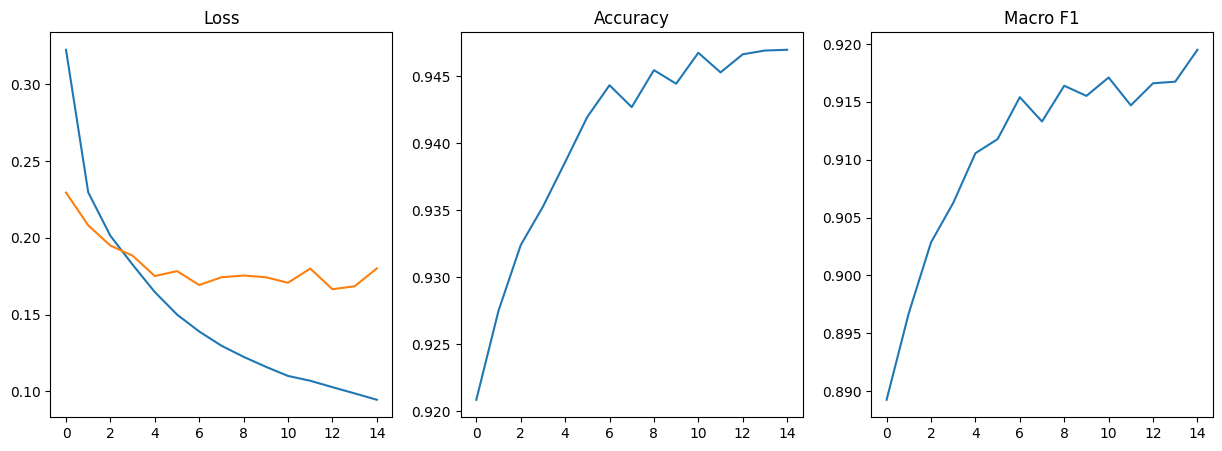

In [49]:
# For Extreme
BiRNN_ex, best_f1_ex = train_optimized_BiRNN(X_train_ex_seq, X_val_ex_seq, y_train, y_val, "BiRNN - Extreme Skip-gram")

# For Optimum
BiRNN_op, best_f1_op = train_optimized_BiRNN(X_train_op_seq, X_val_op_seq, y_train, y_val, "BiRNN - Optimum Skip-gram")

In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize
import gc
import torch.optim as optim

from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight


# **Bi-directional GRU (Skip-gram)**

In [51]:
class ImprovedBiGRU(nn.Module):
    def __init__(self, input_size=300, hidden_size=256, num_layers=3,
                 num_classes=4, dropout=0.4):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.layer_norm = nn.LayerNorm(hidden_size * 2)

        # Reduced dropout (more stable)
        self.dropout = nn.Dropout(dropout)

        # Stronger classifier head
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        gru_out, _ = self.gru(x)

        # Combine mean + max pooling (important improvement)
        mean_pool = torch.mean(gru_out, dim=1)
        max_pool, _ = torch.max(gru_out, dim=1)

        out = mean_pool + max_pool   # feature fusion

        out = self.layer_norm(out)
        out = self.dropout(out)

        out = self.fc(out)

        return out
Bi_GRU = ImprovedBiGRU(dropout=0.4)

summary(Bi_GRU, 
        input_size=(64, 35, 300), 
        device='cuda' if torch.cuda.is_available() else 'cpu',
        col_names=["input_size", "output_size", "num_params", "trainable"],
        depth=4)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ImprovedBiGRU                            [64, 35, 300]             [64, 4]                   --                        True
├─GRU: 1-1                               [64, 35, 300]             [64, 35, 512]             3,222,528                 True
├─LayerNorm: 1-2                         [64, 512]                 [64, 512]                 1,024                     True
├─Dropout: 1-3                           [64, 512]                 [64, 512]                 --                        --
├─Sequential: 1-4                        [64, 512]                 [64, 4]                   --                        True
│    └─Linear: 2-1                       [64, 512]                 [64, 256]                 131,328                   True
│    └─ReLU: 2-2                         [64, 256]                 [64, 256]                 --                        --
│    └─

In [52]:
'''class ImprovedBiGRU(nn.Module):
    def __init__(self, input_size=300, hidden_size=256, num_layers=3, 
                 num_classes=4, dropout=0.6):
        super().__init__()
        
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.layer_norm = nn.LayerNorm(hidden_size * 2)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(0.5)
        
        self.fc1 = nn.Linear(hidden_size * 2, 128)
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        gru_out, _ = self.gru(x)
        out = gru_out.mean(dim=1)                    # Mean pooling
        out = self.layer_norm(out)
        out = self.dropout1(out)
        out = torch.relu(self.fc1(out))
        out = self.dropout2(out)
        out = self.fc2(out)
        return out
model2 = ImprovedBiGRU(dropout=0.6)

summary(model2, 
        input_size=(64, 35, 300), 
        device='cuda' if torch.cuda.is_available() else 'cpu',
        col_names=["input_size", "output_size", "num_params", "trainable"],
        depth=4)'''

'class ImprovedBiGRU(nn.Module):\n    def __init__(self, input_size=300, hidden_size=256, num_layers=3, \n                 num_classes=4, dropout=0.6):\n        super().__init__()\n\n        self.gru = nn.GRU(\n            input_size=input_size,\n            hidden_size=hidden_size,\n            num_layers=num_layers,\n            batch_first=True,\n            bidirectional=True,\n            dropout=dropout if num_layers > 1 else 0\n        )\n\n        self.layer_norm = nn.LayerNorm(hidden_size * 2)\n        self.dropout1 = nn.Dropout(dropout)\n        self.dropout2 = nn.Dropout(0.5)\n\n        self.fc1 = nn.Linear(hidden_size * 2, 128)\n        self.fc2 = nn.Linear(128, num_classes)\n\n    def forward(self, x):\n        gru_out, _ = self.gru(x)\n        out = gru_out.mean(dim=1)                    # Mean pooling\n        out = self.layer_norm(out)\n        out = self.dropout1(out)\n        out = torch.relu(self.fc1(out))\n        out = self.dropout2(out)\n        out = self.fc2(out

In [53]:
def train_improved_BiGRU(X_train_seq, X_val_seq, y_train, y_val, name, epochs=12):
    print(f"\n{'='*85}")
    print(f"Training Improved BiGRU → {name}")
    print(f"{'='*85}")

    # Convert to tensors
    X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val_seq,   dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_val_t   = torch.tensor(y_val,   dtype=torch.long)

    # DataLoaders
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)

    Bi_GRU = ImprovedBiGRU(dropout=0.4)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    Bi_GRU.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(Bi_GRU.parameters(), lr=0.0003, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

    best_f1 = 0.0
    patience_counter = 0
    best_model_state = None

    train_losses, val_losses, val_f1s = [], [], []

    for epoch in range(epochs):
        # Training Phase
        Bi_GRU.train()
        train_loss = 0.0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            outputs = Bi_GRU(bx)
            loss = criterion(outputs, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(Bi_GRU.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Validation Phase
        Bi_GRU.eval()
        y_true, y_pred = [], []
        val_loss = 0.0

        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                outputs = Bi_GRU(bx)
                loss = criterion(outputs, by)
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                y_true.extend(by.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        val_loss /= len(val_loader)
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')
        cm = confusion_matrix(y_true, y_pred)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_f1s.append(f1)

        scheduler.step(val_loss)

        print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Acc: {acc:.4f} | Macro F1: {f1:.4f}")

        # Early Stopping
        if f1 > best_f1:
            best_f1 = f1
            best_model_state = copy.deepcopy(Bi_GRU.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 5:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    # Load best weights
    Bi_GRU.load_state_dict(best_model_state)

    # Final Results
    print(f"\nFinal Results - {name}")
    print(f"Final Accuracy : {acc:.4f}")
    print(f"Best Macro F1 : {best_f1:.4f}")
    print(classification_report(y_true, y_pred, digits=4))
    print("\nConfusion Matrix:")
    print(cm)
    # Plot Curves
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(train_losses, label='Train Loss', color='blue')
    plt.plot(val_losses, label='Val Loss', color='red')
    plt.title('Loss Curve')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(val_f1s, label='Macro F1 Score', color='green')
    plt.title('Macro F1 Curve')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return Bi_GRU, best_f1

 Starting Improved Bi GRU Training on All 3 Versions...

=== RAW Skip-gram ===

Training Improved BiGRU → BiGRU - Raw Skip-gram


f:\CSE440\dl_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  1/12 | Train Loss: 0.3228 | Val Loss: 0.2489 | Acc: 0.9151 | Macro F1: 0.8806
Epoch  2/12 | Train Loss: 0.2561 | Val Loss: 0.2346 | Acc: 0.9182 | Macro F1: 0.8830
Epoch  3/12 | Train Loss: 0.2395 | Val Loss: 0.2198 | Acc: 0.9213 | Macro F1: 0.8899
Epoch  4/12 | Train Loss: 0.2273 | Val Loss: 0.2204 | Acc: 0.9225 | Macro F1: 0.8895
Epoch  5/12 | Train Loss: 0.2186 | Val Loss: 0.2324 | Acc: 0.9138 | Macro F1: 0.8702
Epoch  6/12 | Train Loss: 0.2126 | Val Loss: 0.2152 | Acc: 0.9205 | Macro F1: 0.8892
Epoch  7/12 | Train Loss: 0.2036 | Val Loss: 0.2016 | Acc: 0.9275 | Macro F1: 0.8957
Epoch  8/12 | Train Loss: 0.1970 | Val Loss: 0.1978 | Acc: 0.9305 | Macro F1: 0.8997
Epoch  9/12 | Train Loss: 0.1904 | Val Loss: 0.2032 | Acc: 0.9280 | Macro F1: 0.8933
Epoch 10/12 | Train Loss: 0.1848 | Val Loss: 0.1980 | Acc: 0.9287 | Macro F1: 0.8981
Epoch 11/12 | Train Loss: 0.1792 | Val Loss: 0.1950 | Acc: 0.9308 | Macro F1: 0.8980
Epoch 12/12 | Train Loss: 0.1737 | Val Loss: 0.1882 | Acc: 0.9344

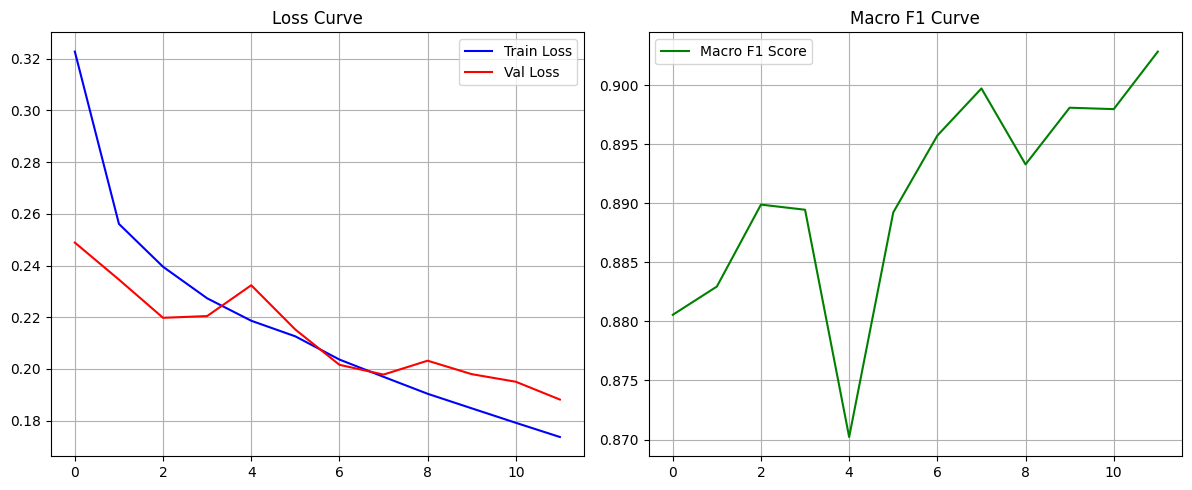


=== EXTREME Skip-gram ===

Training Improved BiGRU → BiGRU - Extreme Skip-gram


f:\CSE440\dl_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  1/12 | Train Loss: 0.3859 | Val Loss: 0.3032 | Acc: 0.8982 | Macro F1: 0.8608
Epoch  2/12 | Train Loss: 0.3142 | Val Loss: 0.3113 | Acc: 0.8951 | Macro F1: 0.8557
Epoch  3/12 | Train Loss: 0.2987 | Val Loss: 0.2805 | Acc: 0.9066 | Macro F1: 0.8704
Epoch  4/12 | Train Loss: 0.2880 | Val Loss: 0.2793 | Acc: 0.9068 | Macro F1: 0.8726
Epoch  5/12 | Train Loss: 0.2776 | Val Loss: 0.2670 | Acc: 0.9125 | Macro F1: 0.8788
Epoch  6/12 | Train Loss: 0.2702 | Val Loss: 0.2582 | Acc: 0.9138 | Macro F1: 0.8806
Epoch  7/12 | Train Loss: 0.2602 | Val Loss: 0.2560 | Acc: 0.9129 | Macro F1: 0.8787
Epoch  8/12 | Train Loss: 0.2524 | Val Loss: 0.2444 | Acc: 0.9164 | Macro F1: 0.8824
Epoch  9/12 | Train Loss: 0.2431 | Val Loss: 0.2489 | Acc: 0.9153 | Macro F1: 0.8818
Epoch 10/12 | Train Loss: 0.2399 | Val Loss: 0.2432 | Acc: 0.9183 | Macro F1: 0.8826
Epoch 11/12 | Train Loss: 0.2333 | Val Loss: 0.2442 | Acc: 0.9198 | Macro F1: 0.8864
Epoch 12/12 | Train Loss: 0.2287 | Val Loss: 0.2413 | Acc: 0.9186

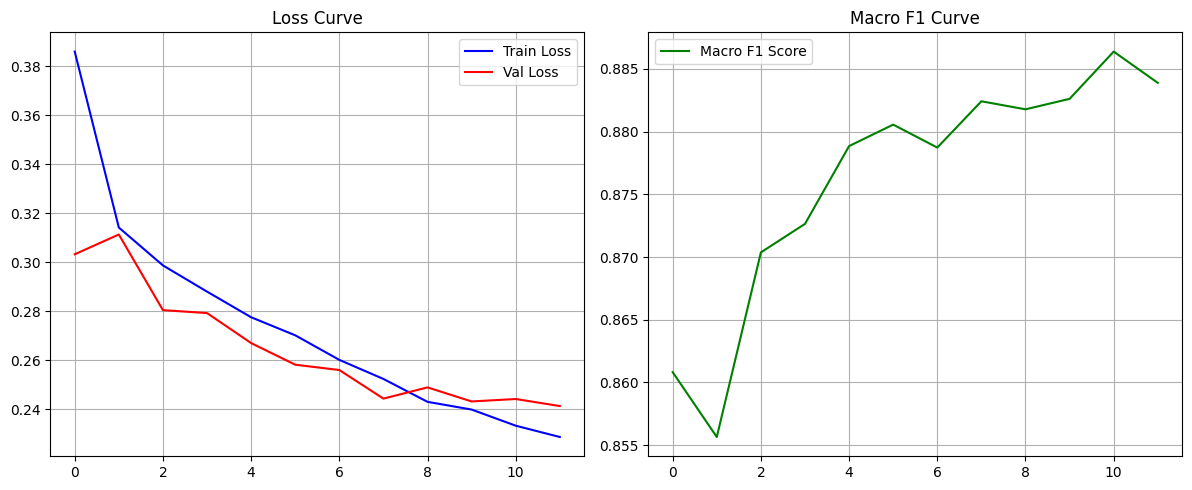


=== OPTIMUM Skip-gram ===

Training Improved BiGRU → BiGRU - Optimum Skip-gram


f:\CSE440\dl_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  1/12 | Train Loss: 0.3278 | Val Loss: 0.2744 | Acc: 0.9071 | Macro F1: 0.8676
Epoch  2/12 | Train Loss: 0.2644 | Val Loss: 0.2331 | Acc: 0.9215 | Macro F1: 0.8902
Epoch  3/12 | Train Loss: 0.2484 | Val Loss: 0.2329 | Acc: 0.9227 | Macro F1: 0.8918
Epoch  4/12 | Train Loss: 0.2398 | Val Loss: 0.2300 | Acc: 0.9216 | Macro F1: 0.8883
Epoch  5/12 | Train Loss: 0.2305 | Val Loss: 0.2151 | Acc: 0.9255 | Macro F1: 0.8935
Epoch  6/12 | Train Loss: 0.2204 | Val Loss: 0.2104 | Acc: 0.9267 | Macro F1: 0.8948
Epoch  7/12 | Train Loss: 0.2146 | Val Loss: 0.2030 | Acc: 0.9284 | Macro F1: 0.8975
Epoch  8/12 | Train Loss: 0.2069 | Val Loss: 0.2041 | Acc: 0.9310 | Macro F1: 0.9004
Epoch  9/12 | Train Loss: 0.2014 | Val Loss: 0.1999 | Acc: 0.9292 | Macro F1: 0.8992
Epoch 10/12 | Train Loss: 0.1956 | Val Loss: 0.2051 | Acc: 0.9298 | Macro F1: 0.8985
Epoch 11/12 | Train Loss: 0.1896 | Val Loss: 0.2177 | Acc: 0.9261 | Macro F1: 0.8921
Epoch 12/12 | Train Loss: 0.1844 | Val Loss: 0.1892 | Acc: 0.9339

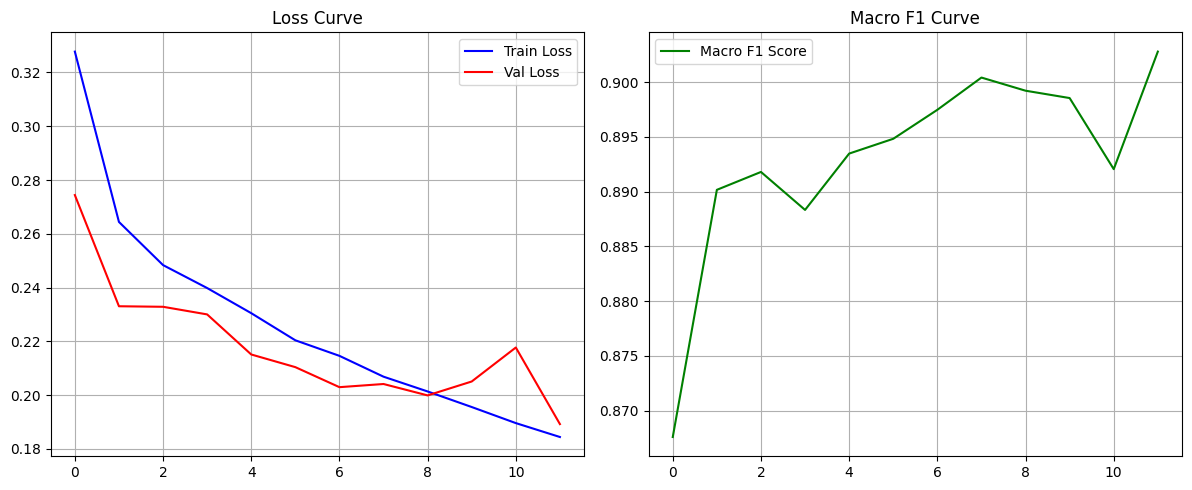


 Training Completed for All Three Versions!


In [54]:
print(" Starting Improved Bi GRU Training on All 3 Versions...\n")

# ====================== 1. RAW ======================
print("=== RAW Skip-gram ===")
BiGRUraw, f1_raw = train_improved_BiGRU(
    X_train_raw_seq, X_val_raw_seq, y_train, y_val, 
    name="BiGRU - Raw Skip-gram"
)

# ====================== 2. EXTREME ======================
print("\n=== EXTREME Skip-gram ===")
BiGRUex, f1_ex = train_improved_BiGRU(
    X_train_ex_seq, X_val_ex_seq, y_train, y_val, 
    name="BiGRU - Extreme Skip-gram"
)

# ====================== 3. OPTIMUM ======================
print("\n=== OPTIMUM Skip-gram ===")
BiGRUop, f1_op = train_improved_BiGRU(
    X_train_op_seq, X_val_op_seq, y_train, y_val, 
    
    
    
    
    
    
    
    
    
    
    name="BiGRU - Optimum Skip-gram"
)

print("\n Training Completed for All Three Versions!")

Instead of using only the last timestep, mean and max pooling were combined to capture both overall sequence information and the most important features, which improved validation performance.

To reduce overfitting, dropout (0.4) and weight decay (1e-4) were applied, as the model showed a tendency to memorize patterns. The learning rate (0.0003) was chosen for stable convergence, since higher values caused fluctuations during training.

Gradient clipping (1.0) was used to prevent exploding gradients, and a learning rate scheduler was applied to reduce the learning rate when validation loss stopped improving.

# **Bidirectional Lstm(Skip-gram)**

In [55]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize
import gc



In [56]:
# ========================= OPTIMIZED BIDIRECTIONAL LSTM =========================
class ImprovedBiLSTM(nn.Module):
    def __init__(self, input_size=300, hidden_size=256, num_layers=3, 
                 num_classes=4, dropout=0.3):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.layer_norm = nn.LayerNorm(hidden_size * 2)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(0.2)
        
        self.fc1 = nn.Linear(hidden_size * 2, 128)
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)                  # (batch, seq_len, hidden*2)
        out = lstm_out.mean(dim=1)                  # Mean pooling (recommended)
        out = self.layer_norm(out)
        out = self.dropout1(out)
        out = torch.relu(self.fc1(out))
        out = self.dropout2(out)
        out = self.fc2(out)
        return out
model4 = ImprovedBiLSTM(dropout=0.3)

summary(model4, 
        input_size=(64, 35, 300), 
        device='cuda' if torch.cuda.is_available() else 'cpu',
        col_names=["input_size", "output_size", "num_params", "trainable"],
        depth=4)



Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ImprovedBiLSTM                           [64, 35, 300]             [64, 4]                   --                        True
├─LSTM: 1-1                              [64, 35, 300]             [64, 35, 512]             4,296,704                 True
├─LayerNorm: 1-2                         [64, 512]                 [64, 512]                 1,024                     True
├─Dropout: 1-3                           [64, 512]                 [64, 512]                 --                        --
├─Linear: 1-4                            [64, 512]                 [64, 128]                 65,664                    True
├─Dropout: 1-5                           [64, 128]                 [64, 128]                 --                        --
├─Linear: 1-6                            [64, 128]                 [64, 4]                   516                       True
Total p

In [57]:
def train_improved_bilstm(X_train_seq, X_val_seq, y_train, y_val, name, epochs=20):
    print(f"\n{'='*90}")
    print(f"Training Improved BiLSTM → {name} (Max 20 epochs)")
    print(f"{'='*90}")

    # Convert to tensors
    X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val_seq,   dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_val_t   = torch.tensor(y_val,   dtype=torch.long)

    # DataLoaders
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)

    model5 = ImprovedBiLSTM(dropout=0.6)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model5.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model5.parameters(), lr=0.0005, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

    best_f1 = 0.0
    best_acc = 0.0
    patience_counter = 0
    best_model_state = None

    train_losses, val_losses, val_f1s = [], [], []

    for epoch in range(epochs):
        # Training
        model5.train()
        train_loss = 0.0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            outputs = model5(bx)
            loss = criterion(outputs, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model5.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Validation
        model5.eval()
        y_true, y_pred = [], []
        val_loss = 0.0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                outputs = model5(bx)
                loss = criterion(outputs, by)
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                y_true.extend(by.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        val_loss /= len(val_loader)
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')
        cm = confusion_matrix(y_true, y_pred)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_f1s.append(f1)

        scheduler.step(val_loss)

        print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Acc: {acc:.4f} | Macro F1: {f1:.4f}")

        # Early Stopping
        if f1 > best_f1 + 0.001:
            best_f1 = f1
            best_acc = acc
            best_model_state = copy.deepcopy(model5.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 6:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    # Load best model
    model5.load_state_dict(best_model_state)

    print(f"\nFinal Results - {name}")
    #print(f"Final Accuracy : {acc:.4f}")
    print(f"Best Accuracy : {best_acc:.4f}")
    print(f"Best Macro F1 : {best_f1:.4f}")
    print(classification_report(y_true, y_pred, digits=4))
    print("\nConfusion Matrix:")
    print(cm)

    # Plot Curves
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(train_losses, label='Train Loss', color='blue')
    plt.plot(val_losses, label='Val Loss', color='red')
    plt.title('Loss Curve')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(val_f1s, label='Macro F1 Score', color='green')
    plt.title('Macro F1 Curve')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return model5, best_f1

Starting Improved BiLSTM Training on All 3 Versions...


Training Improved BiLSTM → BiLSTM - Raw Skip-gram (Max 20 epochs)


f:\CSE440\dl_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  1/20 | Train Loss: 0.3181 | Val Loss: 0.2610 | Acc: 0.9117 | Macro F1: 0.8759
Epoch  2/20 | Train Loss: 0.2614 | Val Loss: 0.2475 | Acc: 0.9165 | Macro F1: 0.8834
Epoch  3/20 | Train Loss: 0.2512 | Val Loss: 0.2529 | Acc: 0.9180 | Macro F1: 0.8832
Epoch  4/20 | Train Loss: 0.2413 | Val Loss: 0.2310 | Acc: 0.9183 | Macro F1: 0.8855
Epoch  5/20 | Train Loss: 0.2310 | Val Loss: 0.2224 | Acc: 0.9214 | Macro F1: 0.8876
Epoch  6/20 | Train Loss: 0.2203 | Val Loss: 0.2273 | Acc: 0.9198 | Macro F1: 0.8877
Epoch  7/20 | Train Loss: 0.2107 | Val Loss: 0.2211 | Acc: 0.9242 | Macro F1: 0.8906
Epoch  8/20 | Train Loss: 0.2023 | Val Loss: 0.2077 | Acc: 0.9268 | Macro F1: 0.8936
Epoch  9/20 | Train Loss: 0.1965 | Val Loss: 0.1997 | Acc: 0.9302 | Macro F1: 0.8983
Epoch 10/20 | Train Loss: 0.1917 | Val Loss: 0.2011 | Acc: 0.9306 | Macro F1: 0.8972
Epoch 11/20 | Train Loss: 0.1857 | Val Loss: 0.2047 | Acc: 0.9305 | Macro F1: 0.8968
Epoch 12/20 | Train Loss: 0.1797 | Val Loss: 0.1935 | Acc: 0.9343

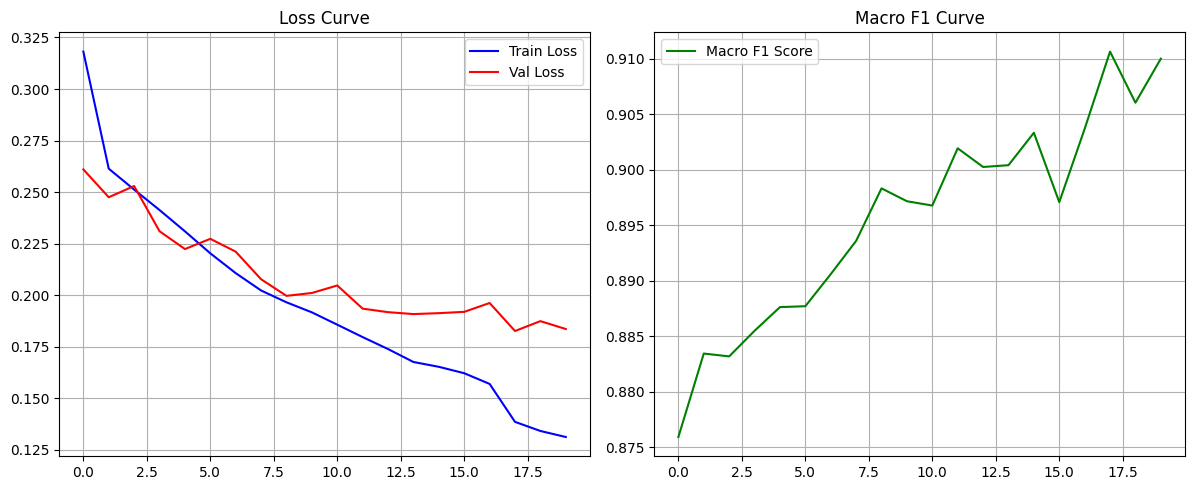


Training Improved BiLSTM → BiLSTM - Extreme Skip-gram (Max 20 epochs)


f:\CSE440\dl_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  1/20 | Train Loss: 0.3854 | Val Loss: 0.3277 | Acc: 0.8920 | Macro F1: 0.8549
Epoch  2/20 | Train Loss: 0.3163 | Val Loss: 0.3073 | Acc: 0.8969 | Macro F1: 0.8595
Epoch  3/20 | Train Loss: 0.3031 | Val Loss: 0.3276 | Acc: 0.8893 | Macro F1: 0.8522
Epoch  4/20 | Train Loss: 0.2915 | Val Loss: 0.2871 | Acc: 0.9062 | Macro F1: 0.8713
Epoch  5/20 | Train Loss: 0.2828 | Val Loss: 0.2862 | Acc: 0.9063 | Macro F1: 0.8679
Epoch  6/20 | Train Loss: 0.2750 | Val Loss: 0.2700 | Acc: 0.9106 | Macro F1: 0.8760
Epoch  7/20 | Train Loss: 0.2679 | Val Loss: 0.2655 | Acc: 0.9134 | Macro F1: 0.8792
Epoch  8/20 | Train Loss: 0.2589 | Val Loss: 0.2689 | Acc: 0.9122 | Macro F1: 0.8759
Epoch  9/20 | Train Loss: 0.2524 | Val Loss: 0.2976 | Acc: 0.9045 | Macro F1: 0.8602
Epoch 10/20 | Train Loss: 0.2454 | Val Loss: 0.2599 | Acc: 0.9182 | Macro F1: 0.8841
Epoch 11/20 | Train Loss: 0.2378 | Val Loss: 0.2538 | Acc: 0.9178 | Macro F1: 0.8850
Epoch 12/20 | Train Loss: 0.2325 | Val Loss: 0.2494 | Acc: 0.9200

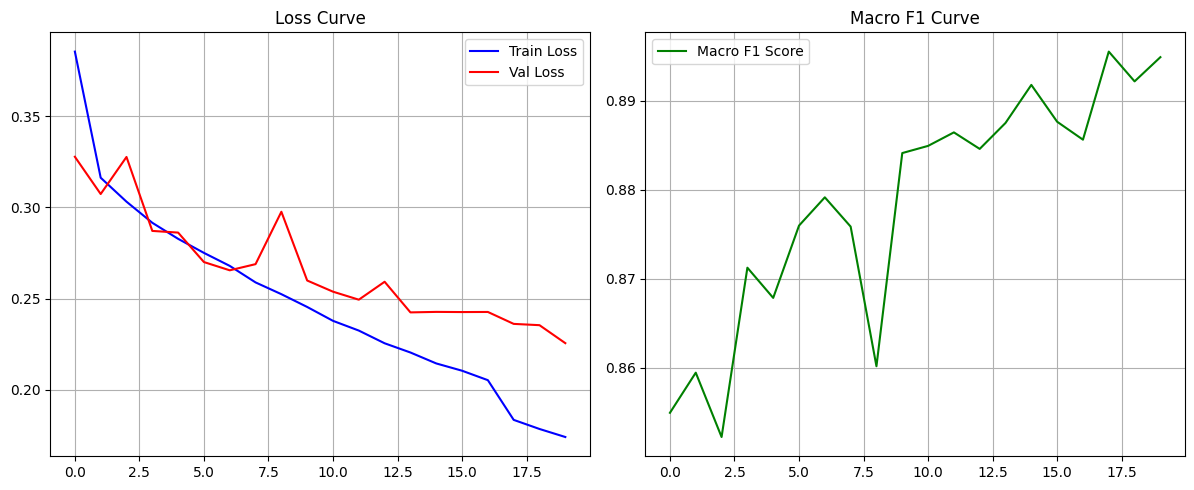


Training Improved BiLSTM → BiLSTM - Optimum Skip-gram (Max 20 epochs)


f:\CSE440\dl_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  1/20 | Train Loss: 0.3260 | Val Loss: 0.2560 | Acc: 0.9128 | Macro F1: 0.8803
Epoch  2/20 | Train Loss: 0.2638 | Val Loss: 0.2591 | Acc: 0.9149 | Macro F1: 0.8786
Epoch  3/20 | Train Loss: 0.2508 | Val Loss: 0.2498 | Acc: 0.9196 | Macro F1: 0.8888
Epoch  4/20 | Train Loss: 0.2382 | Val Loss: 0.2397 | Acc: 0.9239 | Macro F1: 0.8933
Epoch  5/20 | Train Loss: 0.2326 | Val Loss: 0.2270 | Acc: 0.9255 | Macro F1: 0.8941
Epoch  6/20 | Train Loss: 0.2223 | Val Loss: 0.2212 | Acc: 0.9272 | Macro F1: 0.8968
Epoch  7/20 | Train Loss: 0.2120 | Val Loss: 0.2078 | Acc: 0.9305 | Macro F1: 0.9011
Epoch  8/20 | Train Loss: 0.2023 | Val Loss: 0.2119 | Acc: 0.9266 | Macro F1: 0.8930
Epoch  9/20 | Train Loss: 0.1966 | Val Loss: 0.2302 | Acc: 0.9232 | Macro F1: 0.8913
Epoch 10/20 | Train Loss: 0.1882 | Val Loss: 0.2014 | Acc: 0.9315 | Macro F1: 0.9012
Epoch 11/20 | Train Loss: 0.1831 | Val Loss: 0.2034 | Acc: 0.9334 | Macro F1: 0.9021
Epoch 12/20 | Train Loss: 0.1760 | Val Loss: 0.1982 | Acc: 0.9361

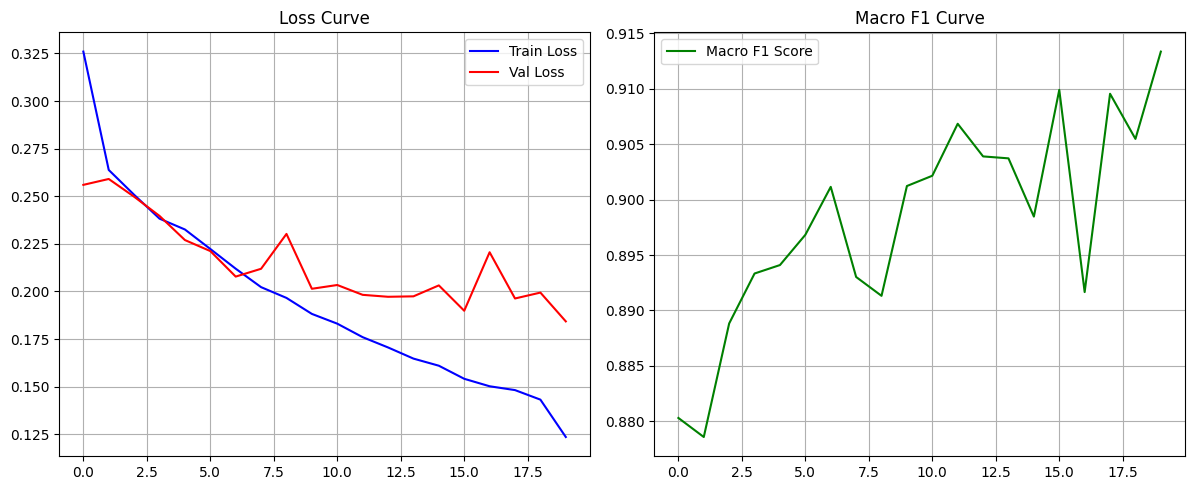


 BiLSTM Training Completed for All Three Versions!


In [58]:
print("Starting Improved BiLSTM Training on All 3 Versions...\n")

# ====================== 1. RAW ======================
bilstm_raw, f1_raw = train_improved_bilstm(
    X_train_raw_seq, X_val_raw_seq, y_train, y_val, 
    name="BiLSTM - Raw Skip-gram"
)

# ====================== 2. EXTREME ======================
bilstm_ex, f1_ex = train_improved_bilstm(
    X_train_ex_seq, X_val_ex_seq, y_train, y_val, 
    name="BiLSTM - Extreme Skip-gram"
)

# ====================== 3. OPTIMUM ======================
bilstm_op, f1_op = train_improved_bilstm(
    X_train_op_seq, X_val_op_seq, y_train, y_val, 
    name="BiLSTM - Optimum Skip-gram"
)

print("\n BiLSTM Training Completed for All Three Versions!")

In the BiLSTM model, the fully connected layer uses 128 neurons to reduce model complexity after the LSTM output. Since BiLSTM already captures rich and detailed contextual information through its gating mechanism, a smaller FC layer is sufficient to process these features. Using 128 helps prevent overfitting and keeps the model more stable. Larger sizes (like 256) increased complexity without improving validation performance

# **Simple RNN(Skip-gram)**

In [59]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score, confusion_matrix    
from sklearn.preprocessing import label_binarize
import gc

print(" Simple RNN imports ready")

 Simple RNN imports ready


In [60]:
# ========================= OPTIMIZED SIMPLE RNN =========================
class OptimizedRNN(nn.Module):
    def __init__(self, input_size=300, hidden_size=256, num_layers=3, 
                 num_classes=4, dropout=0.6):
        super().__init__()
        
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,        # Uni-directional
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(0.5)
        
        self.fc1 = nn.Linear(hidden_size, 128)
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        rnn_out, _ = self.rnn(x)                    # (batch, seq_len, hidden)
        out = rnn_out.mean(dim=1)                   # Mean pooling
        out = self.layer_norm(out)
        out = self.dropout1(out)
        out = torch.relu(self.fc1(out))
        out = self.dropout2(out)
        out = self.fc2(out)
        return out
model6 = OptimizedRNN(dropout=0.6)

summary(model6, 
        input_size=(64, 35, 300), 
        device='cuda' if torch.cuda.is_available() else 'cpu',
        col_names=["input_size", "output_size", "num_params", "trainable"],
        depth=4)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
OptimizedRNN                             [64, 35, 300]             [64, 4]                   --                        True
├─RNN: 1-1                               [64, 35, 300]             [64, 35, 256]             406,016                   True
├─LayerNorm: 1-2                         [64, 256]                 [64, 256]                 512                       True
├─Dropout: 1-3                           [64, 256]                 [64, 256]                 --                        --
├─Linear: 1-4                            [64, 256]                 [64, 128]                 32,896                    True
├─Dropout: 1-5                           [64, 128]                 [64, 128]                 --                        --
├─Linear: 1-6                            [64, 128]                 [64, 4]                   516                       True
Total p

In [61]:
def train_unidirectional_rnn(X_train_seq, X_val_seq, y_train, y_val, name, epochs=20):
    print(f"\n{'='*90}")
    print(f"Training Uni-directional RNN → {name} (Max 20 epochs)")
    print(f"{'='*90}")

    # Convert to tensors
    X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val_seq,   dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_val_t   = torch.tensor(y_val,   dtype=torch.long)

    # DataLoaders
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)

    model7 = OptimizedRNN(dropout=0.6)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model7.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model7.parameters(), lr=0.0005, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

    best_f1 = 0.0
    patience_counter = 0
    best_model_state = None

    train_losses, val_losses, val_f1s = [], [], []

    for epoch in range(epochs):
        # Training
        model7.train()
        train_loss = 0.0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            outputs = model7(bx)
            loss = criterion(outputs, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model7.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Validation
        model7.eval()
        y_true, y_pred = [], []
        val_loss = 0.0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                outputs = model7(bx)
                loss = criterion(outputs, by)
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                y_true.extend(by.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        val_loss /= len(val_loader)
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')
        cm = confusion_matrix(y_true, y_pred)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_f1s.append(f1)

        scheduler.step(val_loss)

        print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Acc: {acc:.4f} | Macro F1: {f1:.4f}")

        # Early Stopping
        if f1 > best_f1 + 0.001:
            best_f1 = f1
            best_model_state = copy.deepcopy(model7.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 6:
                print(f" Early stopping triggered at epoch {epoch+1}")
                break

    # Load best model
    model7.load_state_dict(best_model_state)

    print(f"\nFinal Results - {name}")
    print(f"Final Accuracy : {acc:.4f}")
    print(f"Best Macro F1 : {best_f1:.4f}")
    print(classification_report(y_true, y_pred, digits=4))
    print("\nConfusion Matrix:")
    print(cm)

    # Plot Curves
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(train_losses, label='Train Loss', color='blue')
    plt.plot(val_losses, label='Val Loss', color='red')
    plt.title('Loss Curve')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(val_f1s, label='Macro F1 Score', color='green')
    plt.title('Macro F1 Curve')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return model7, best_f1

 Starting Uni-directional RNN Training on All 3 Versions...


Training Uni-directional RNN → Uni-RNN - Raw Skip-gram (Max 20 epochs)


f:\CSE440\dl_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  1/20 | Train Loss: 0.3744 | Val Loss: 0.2759 | Acc: 0.9074 | Macro F1: 0.8685
Epoch  2/20 | Train Loss: 0.2994 | Val Loss: 0.2774 | Acc: 0.9068 | Macro F1: 0.8719
Epoch  3/20 | Train Loss: 0.2868 | Val Loss: 0.2688 | Acc: 0.9108 | Macro F1: 0.8725
Epoch  4/20 | Train Loss: 0.2829 | Val Loss: 0.2743 | Acc: 0.9097 | Macro F1: 0.8748
Epoch  5/20 | Train Loss: 0.2777 | Val Loss: 0.2681 | Acc: 0.9112 | Macro F1: 0.8752
Epoch  6/20 | Train Loss: 0.2765 | Val Loss: 0.2501 | Acc: 0.9137 | Macro F1: 0.8781
Epoch  7/20 | Train Loss: 0.2726 | Val Loss: 0.2776 | Acc: 0.9028 | Macro F1: 0.8624
Epoch  8/20 | Train Loss: 0.2708 | Val Loss: 0.2521 | Acc: 0.9140 | Macro F1: 0.8814
Epoch  9/20 | Train Loss: 0.2693 | Val Loss: 0.2791 | Acc: 0.9034 | Macro F1: 0.8691
Epoch 10/20 | Train Loss: 0.2528 | Val Loss: 0.2399 | Acc: 0.9177 | Macro F1: 0.8842
Epoch 11/20 | Train Loss: 0.2498 | Val Loss: 0.2431 | Acc: 0.9170 | Macro F1: 0.8825
Epoch 12/20 | Train Loss: 0.2453 | Val Loss: 0.2366 | Acc: 0.9183

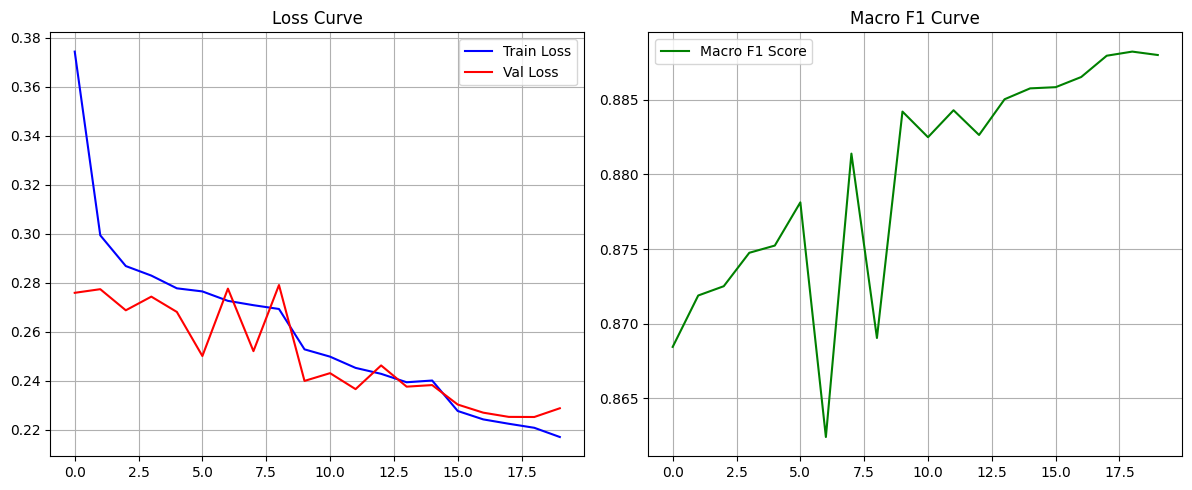


Training Uni-directional RNN → Uni-RNN - Extreme Skip-gram (Max 20 epochs)


f:\CSE440\dl_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  1/20 | Train Loss: 0.4505 | Val Loss: 0.3469 | Acc: 0.8815 | Macro F1: 0.8349
Epoch  2/20 | Train Loss: 0.3623 | Val Loss: 0.3372 | Acc: 0.8862 | Macro F1: 0.8404
Epoch  3/20 | Train Loss: 0.3510 | Val Loss: 0.3204 | Acc: 0.8924 | Macro F1: 0.8506
Epoch  4/20 | Train Loss: 0.3421 | Val Loss: 0.3643 | Acc: 0.8749 | Macro F1: 0.8248
Epoch  5/20 | Train Loss: 0.3369 | Val Loss: 0.3298 | Acc: 0.8919 | Macro F1: 0.8539
Epoch  6/20 | Train Loss: 0.3322 | Val Loss: 0.3116 | Acc: 0.8955 | Macro F1: 0.8589
Epoch  7/20 | Train Loss: 0.3290 | Val Loss: 0.3125 | Acc: 0.8991 | Macro F1: 0.8617
Epoch  8/20 | Train Loss: 0.3292 | Val Loss: 0.3138 | Acc: 0.8980 | Macro F1: 0.8596
Epoch  9/20 | Train Loss: 0.3252 | Val Loss: 0.3265 | Acc: 0.8897 | Macro F1: 0.8449
Epoch 10/20 | Train Loss: 0.3078 | Val Loss: 0.3049 | Acc: 0.9000 | Macro F1: 0.8604
Epoch 11/20 | Train Loss: 0.3025 | Val Loss: 0.3018 | Acc: 0.9018 | Macro F1: 0.8659
Epoch 12/20 | Train Loss: 0.2997 | Val Loss: 0.3011 | Acc: 0.9001

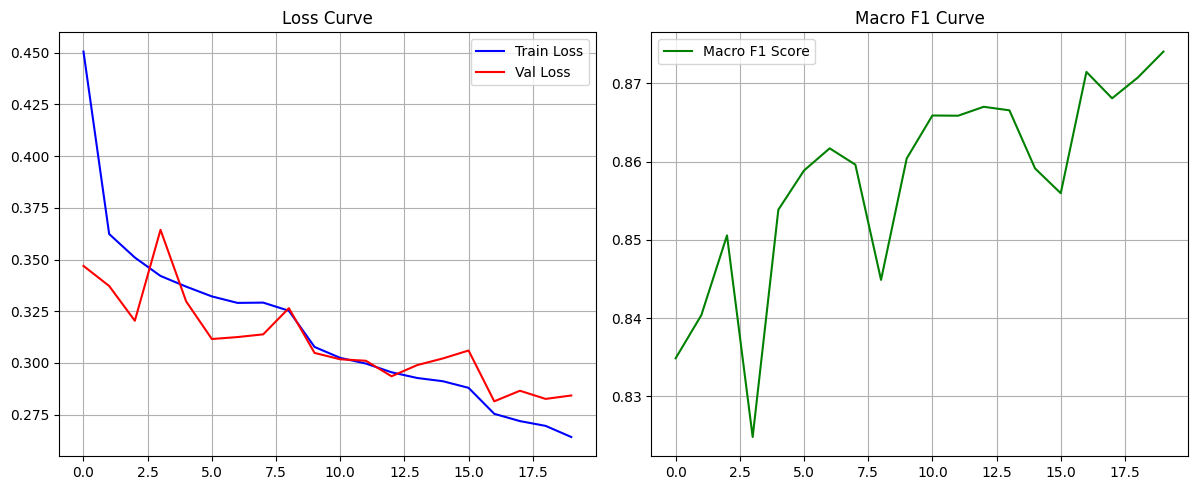


Training Uni-directional RNN → Uni-RNN - Optimum Skip-gram (Max 20 epochs)


f:\CSE440\dl_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  1/20 | Train Loss: 0.3740 | Val Loss: 0.3047 | Acc: 0.9025 | Macro F1: 0.8697
Epoch  2/20 | Train Loss: 0.3062 | Val Loss: 0.2665 | Acc: 0.9122 | Macro F1: 0.8787
Epoch  3/20 | Train Loss: 0.2948 | Val Loss: 0.2915 | Acc: 0.8980 | Macro F1: 0.8598
Epoch  4/20 | Train Loss: 0.2867 | Val Loss: 0.2672 | Acc: 0.9126 | Macro F1: 0.8779
Epoch  5/20 | Train Loss: 0.2813 | Val Loss: 0.2853 | Acc: 0.9046 | Macro F1: 0.8706
Epoch  6/20 | Train Loss: 0.2644 | Val Loss: 0.2530 | Acc: 0.9182 | Macro F1: 0.8868
Epoch  7/20 | Train Loss: 0.2593 | Val Loss: 0.2596 | Acc: 0.9133 | Macro F1: 0.8793
Epoch  8/20 | Train Loss: 0.2588 | Val Loss: 0.2514 | Acc: 0.9164 | Macro F1: 0.8833
Epoch  9/20 | Train Loss: 0.2542 | Val Loss: 0.2487 | Acc: 0.9153 | Macro F1: 0.8844
Epoch 10/20 | Train Loss: 0.2525 | Val Loss: 0.2421 | Acc: 0.9183 | Macro F1: 0.8859
Epoch 11/20 | Train Loss: 0.2502 | Val Loss: 0.2529 | Acc: 0.9162 | Macro F1: 0.8849
Epoch 12/20 | Train Loss: 0.2468 | Val Loss: 0.2548 | Acc: 0.9150

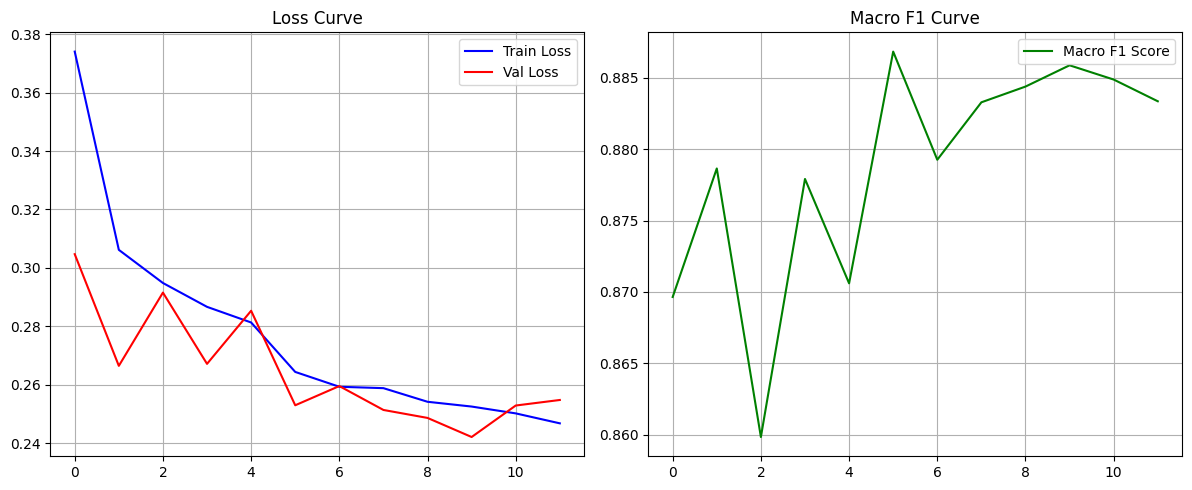


 Uni-directional RNN Training Completed for All Three Versions!


In [62]:
print(" Starting Uni-directional RNN Training on All 3 Versions...\n")

# ====================== 1. RAW ======================
rnn_raw, f1_raw = train_unidirectional_rnn(
    X_train_raw_seq, X_val_raw_seq, y_train, y_val, 
    name="Uni-RNN - Raw Skip-gram"
)

# ====================== 2. EXTREME ======================
rnn_ex, f1_ex = train_unidirectional_rnn(
    X_train_ex_seq, X_val_ex_seq, y_train, y_val, 
    name="Uni-RNN - Extreme Skip-gram"
)

# ====================== 3. OPTIMUM ======================
rnn_op, f1_op = train_unidirectional_rnn(
    X_train_op_seq, X_val_op_seq, y_train, y_val, 
    name="Uni-RNN - Optimum Skip-gram"
)

print("\n Uni-directional RNN Training Completed for All Three Versions!")

A relatively high (0.6) dropout rate was used to counteract the increased model capacity from stacked recurrent and dense layers, ensuring robust feature learning and improved generalization. A stronger dropout (0.6) was applied after sequence representation to regularize high-dimensional features, while a slightly lower dropout (0.5) was used before classification to preserve important information. This combination improved generalization and training stability.
Mean pooling was used to capture information from the entire sequence in a stable and simple way, avoiding the limitations of last timestep and unnecessary complexity. Combining mean + max increases complexity without significant improvement for simple RNN

# **GRU(Skip-gram)**

In [63]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize
import gc

print("  GRU imports ready")

  GRU imports ready


In [64]:
# ========================= OPTIMIZED  GRU =========================
class OptimizedGRU(nn.Module):
    def __init__(self, input_size=300, hidden_size=256, num_layers=3, 
                 num_classes=4, dropout=0.6):
        super().__init__()
        
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,        # Uni-directional
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(0.5)
        
        self.fc1 = nn.Linear(hidden_size, 128)
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        gru_out, _ = self.gru(x)                    # (batch, seq_len, hidden)
        out = gru_out.mean(dim=1)                   # Mean pooling
        out = self.layer_norm(out)
        out = self.dropout1(out)
        out = torch.relu(self.fc1(out))
        out = self.dropout2(out)
        out = self.fc2(out)
        return out
model8 = OptimizedGRU(dropout=0.6)

summary(model8, 
        input_size=(64, 35, 300), 
        device='cuda' if torch.cuda.is_available() else 'cpu',
        col_names=["input_size", "output_size", "num_params", "trainable"],
        depth=4)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
OptimizedGRU                             [64, 35, 300]             [64, 4]                   --                        True
├─GRU: 1-1                               [64, 35, 300]             [64, 35, 256]             1,218,048                 True
├─LayerNorm: 1-2                         [64, 256]                 [64, 256]                 512                       True
├─Dropout: 1-3                           [64, 256]                 [64, 256]                 --                        --
├─Linear: 1-4                            [64, 256]                 [64, 128]                 32,896                    True
├─Dropout: 1-5                           [64, 128]                 [64, 128]                 --                        --
├─Linear: 1-6                            [64, 128]                 [64, 4]                   516                       True
Total p

In [65]:
def train_gru(X_train_seq, X_val_seq, y_train, y_val, name, epochs=20):
    print(f"\n{'='*90}")
    print(f"Training Uni-directional GRU → {name} (Max 20 epochs)")
    print(f"{'='*90}")

    # Convert to tensors
    X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val_seq,   dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_val_t   = torch.tensor(y_val,   dtype=torch.long)

    # DataLoaders
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)

    model9 = OptimizedGRU(dropout=0.6)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model9.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model9.parameters(), lr=0.0005, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

    best_f1 = 0.0
    patience_counter = 0
    best_model_state = None

    train_losses, val_losses, val_f1s = [], [], []

    for epoch in range(epochs):
        # Training
        model9.train()
        train_loss = 0.0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            outputs = model9(bx)
            loss = criterion(outputs, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model9.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Validation
        model9.eval()
        y_true, y_pred = [], []
        val_loss = 0.0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                outputs = model9(bx)
                loss = criterion(outputs, by)
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                y_true.extend(by.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        val_loss /= len(val_loader)
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')
        cm = confusion_matrix(y_true, y_pred)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_f1s.append(f1)

        scheduler.step(val_loss)

        print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Acc: {acc:.4f} | Macro F1: {f1:.4f}")

        # Early Stopping
        if f1 > best_f1 + 0.001:
            best_f1 = f1
            best_model_state = copy.deepcopy(model9.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 6:
                print(f" Early stopping triggered at epoch {epoch+1}")
                break

    # Load best model
    model9.load_state_dict(best_model_state)

    print(f"\n Final Results - {name}")
    print(f"Final Accuracy : {acc:.4f}")
    print(f"Best Macro F1 : {best_f1:.4f}")
    print(classification_report(y_true, y_pred, digits=4))
    print("\nConfusion Matrix:")
    print(cm)

    # Plot Curves
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(train_losses, label='Train Loss', color='blue')
    plt.plot(val_losses, label='Val Loss', color='red')
    plt.title('Loss Curve')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(val_f1s, label='Macro F1 Score', color='green')
    plt.title('Macro F1 Curve')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return model9, best_f1

Uni-directional GRU Training on All 3 Versions...


Training Uni-directional GRU → Uni-GRU - Raw Skip-gram (Max 20 epochs)


f:\CSE440\dl_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  1/20 | Train Loss: 0.3376 | Val Loss: 0.2646 | Acc: 0.9113 | Macro F1: 0.8773
Epoch  2/20 | Train Loss: 0.2730 | Val Loss: 0.2425 | Acc: 0.9165 | Macro F1: 0.8822
Epoch  3/20 | Train Loss: 0.2577 | Val Loss: 0.2421 | Acc: 0.9174 | Macro F1: 0.8846
Epoch  4/20 | Train Loss: 0.2454 | Val Loss: 0.2326 | Acc: 0.9187 | Macro F1: 0.8862
Epoch  5/20 | Train Loss: 0.2345 | Val Loss: 0.2238 | Acc: 0.9212 | Macro F1: 0.8871
Epoch  6/20 | Train Loss: 0.2240 | Val Loss: 0.2126 | Acc: 0.9255 | Macro F1: 0.8927
Epoch  7/20 | Train Loss: 0.2159 | Val Loss: 0.2105 | Acc: 0.9287 | Macro F1: 0.8980
Epoch  8/20 | Train Loss: 0.2055 | Val Loss: 0.2129 | Acc: 0.9285 | Macro F1: 0.8960
Epoch  9/20 | Train Loss: 0.1980 | Val Loss: 0.2118 | Acc: 0.9263 | Macro F1: 0.8932
Epoch 10/20 | Train Loss: 0.1908 | Val Loss: 0.1981 | Acc: 0.9328 | Macro F1: 0.9010
Epoch 11/20 | Train Loss: 0.1839 | Val Loss: 0.1988 | Acc: 0.9337 | Macro F1: 0.9023
Epoch 12/20 | Train Loss: 0.1766 | Val Loss: 0.2015 | Acc: 0.9333

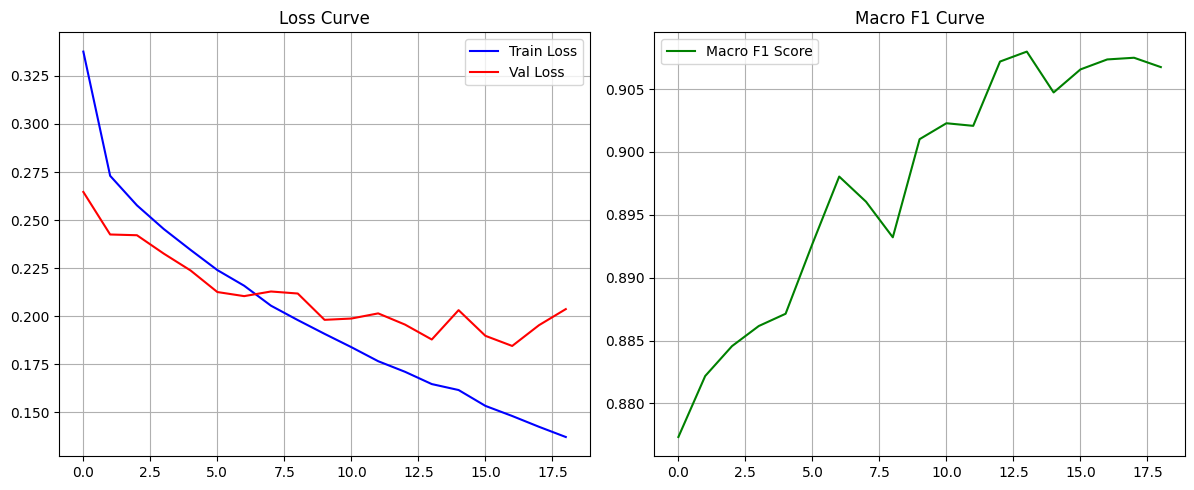


Training Uni-directional GRU → Uni-GRU - Extreme Skip-gram (Max 20 epochs)


f:\CSE440\dl_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  1/20 | Train Loss: 0.3971 | Val Loss: 0.3238 | Acc: 0.8912 | Macro F1: 0.8518
Epoch  2/20 | Train Loss: 0.3246 | Val Loss: 0.2928 | Acc: 0.9030 | Macro F1: 0.8665
Epoch  3/20 | Train Loss: 0.3068 | Val Loss: 0.2954 | Acc: 0.9064 | Macro F1: 0.8682
Epoch  4/20 | Train Loss: 0.2944 | Val Loss: 0.2747 | Acc: 0.9088 | Macro F1: 0.8738
Epoch  5/20 | Train Loss: 0.2821 | Val Loss: 0.2689 | Acc: 0.9108 | Macro F1: 0.8727
Epoch  6/20 | Train Loss: 0.2720 | Val Loss: 0.2620 | Acc: 0.9141 | Macro F1: 0.8782
Epoch  7/20 | Train Loss: 0.2632 | Val Loss: 0.2657 | Acc: 0.9125 | Macro F1: 0.8784
Epoch  8/20 | Train Loss: 0.2510 | Val Loss: 0.2580 | Acc: 0.9174 | Macro F1: 0.8809
Epoch  9/20 | Train Loss: 0.2458 | Val Loss: 0.2529 | Acc: 0.9195 | Macro F1: 0.8851
Epoch 10/20 | Train Loss: 0.2376 | Val Loss: 0.2421 | Acc: 0.9197 | Macro F1: 0.8850
Epoch 11/20 | Train Loss: 0.2289 | Val Loss: 0.2524 | Acc: 0.9211 | Macro F1: 0.8878
Epoch 12/20 | Train Loss: 0.2214 | Val Loss: 0.2525 | Acc: 0.9191

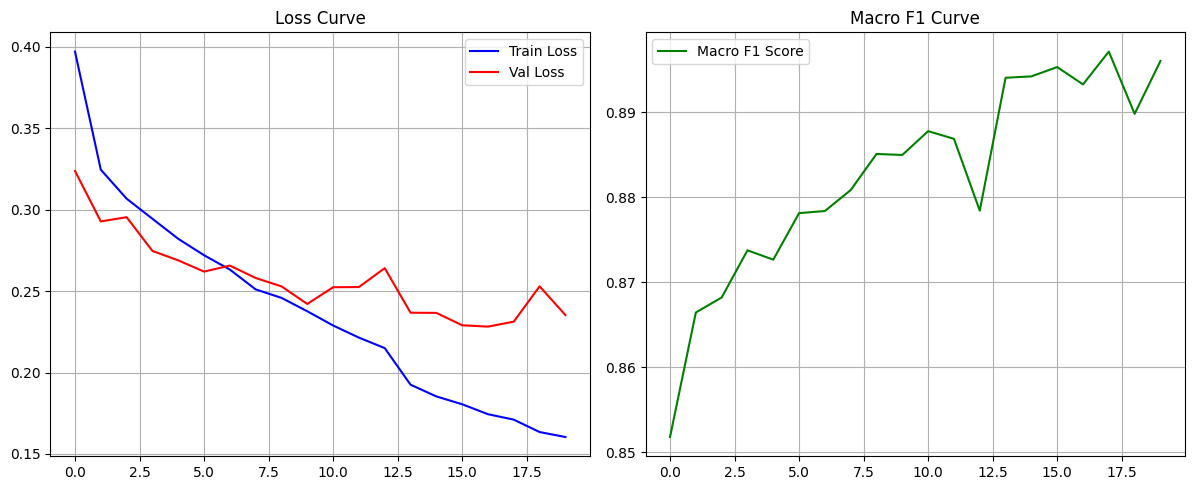


Training Uni-directional GRU → Uni-GRU - Optimum Skip-gram (Max 20 epochs)


f:\CSE440\dl_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  1/20 | Train Loss: 0.3356 | Val Loss: 0.2578 | Acc: 0.9139 | Macro F1: 0.8797
Epoch  2/20 | Train Loss: 0.2719 | Val Loss: 0.2587 | Acc: 0.9160 | Macro F1: 0.8807
Epoch  3/20 | Train Loss: 0.2563 | Val Loss: 0.2478 | Acc: 0.9185 | Macro F1: 0.8863
Epoch  4/20 | Train Loss: 0.2439 | Val Loss: 0.2294 | Acc: 0.9218 | Macro F1: 0.8911
Epoch  5/20 | Train Loss: 0.2350 | Val Loss: 0.2224 | Acc: 0.9251 | Macro F1: 0.8946
Epoch  6/20 | Train Loss: 0.2260 | Val Loss: 0.2115 | Acc: 0.9292 | Macro F1: 0.8992
Epoch  7/20 | Train Loss: 0.2146 | Val Loss: 0.2196 | Acc: 0.9269 | Macro F1: 0.8951
Epoch  8/20 | Train Loss: 0.2049 | Val Loss: 0.2073 | Acc: 0.9322 | Macro F1: 0.9018
Epoch  9/20 | Train Loss: 0.1972 | Val Loss: 0.1946 | Acc: 0.9347 | Macro F1: 0.9046
Epoch 10/20 | Train Loss: 0.1883 | Val Loss: 0.1939 | Acc: 0.9341 | Macro F1: 0.9036
Epoch 11/20 | Train Loss: 0.1793 | Val Loss: 0.1882 | Acc: 0.9371 | Macro F1: 0.9067
Epoch 12/20 | Train Loss: 0.1719 | Val Loss: 0.1909 | Acc: 0.9345

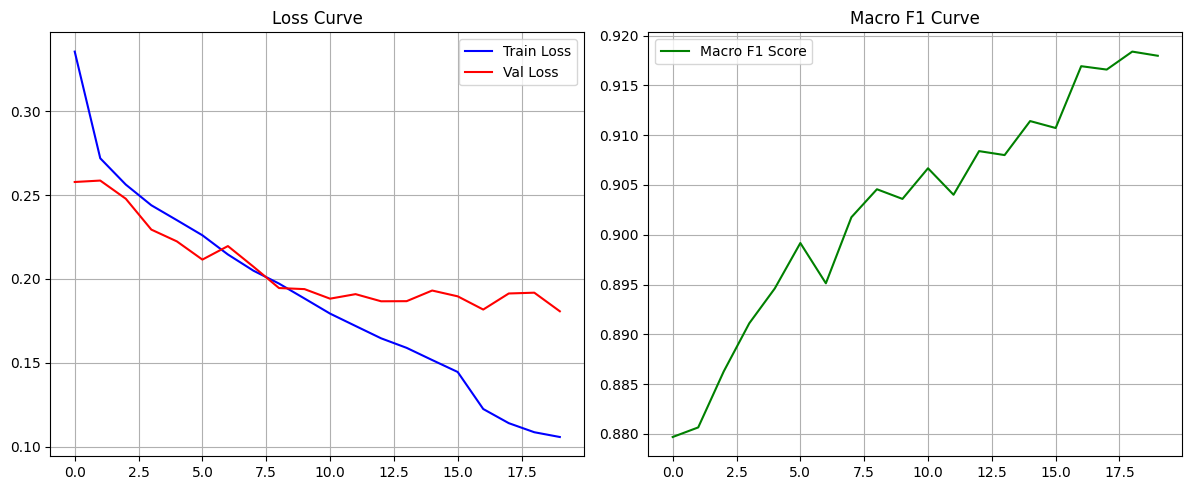


 GRU Training Completed for All Three Versions!


In [66]:
print("Uni-directional GRU Training on All 3 Versions...\n")

# ====================== 1. RAW ======================
gru_raw_uni, f1_raw_uni = train_gru(
    X_train_raw_seq, X_val_raw_seq, y_train, y_val, 
    name="Uni-GRU - Raw Skip-gram"
)

# ====================== 2. EXTREME ======================
gru_ex_uni, f1_ex_uni = train_gru(
    X_train_ex_seq, X_val_ex_seq, y_train, y_val, 
    name="Uni-GRU - Extreme Skip-gram"
)

# ====================== 3. OPTIMUM ======================
gru_op_uni, f1_op_uni = train_gru(
    X_train_op_seq, X_val_op_seq, y_train, y_val, 
    name="Uni-GRU - Optimum Skip-gram"
)

print("\n GRU Training Completed for All Three Versions!")

Apperantly, the hyperparameters for RNN and GRU were kept similar to ensure a fair comparison, so that performance differences reflect the inherent capability of the models rather than differences in configuration.

# **LSTM**

In [67]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize
import gc



In [68]:
# ========================= OPTIMIZED  LSTM =========================
class OptimizedLSTM(nn.Module):
    def __init__(self, input_size=300, hidden_size=256, num_layers=3, 
                 num_classes=4, dropout=0.6):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,       
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(0.5)
        
        self.fc1 = nn.Linear(hidden_size, 128)
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)                  # (batch, seq_len, hidden)
        out = lstm_out.mean(dim=1)                  # Mean pooling
        out = self.layer_norm(out)
        out = self.dropout1(out)
        out = torch.relu(self.fc1(out))
        out = self.dropout2(out)
        out = self.fc2(out)
        return out
model10 = OptimizedLSTM(dropout=0.6)

summary(model10, 
        input_size=(64, 35, 300), 
        device='cuda' if torch.cuda.is_available() else 'cpu',
        col_names=["input_size", "output_size", "num_params", "trainable"],
        depth=4)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
OptimizedLSTM                            [64, 35, 300]             [64, 4]                   --                        True
├─LSTM: 1-1                              [64, 35, 300]             [64, 35, 256]             1,624,064                 True
├─LayerNorm: 1-2                         [64, 256]                 [64, 256]                 512                       True
├─Dropout: 1-3                           [64, 256]                 [64, 256]                 --                        --
├─Linear: 1-4                            [64, 256]                 [64, 128]                 32,896                    True
├─Dropout: 1-5                           [64, 128]                 [64, 128]                 --                        --
├─Linear: 1-6                            [64, 128]                 [64, 4]                   516                       True
Total p

In [69]:
def train_lstm(X_train_seq, X_val_seq, y_train, y_val, name, epochs=20):
    print(f"\n{'='*90}")
    print(f"Training LSTM → {name} (Max 20 epochs)")
    print(f"{'='*90}")

    # Convert to tensors
    X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val_seq,   dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_val_t   = torch.tensor(y_val,   dtype=torch.long)

    # DataLoaders
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)

    model11 = OptimizedLSTM(dropout=0.6)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model11.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model11.parameters(), lr=0.0005, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5, verbose=True)

    best_f1 = 0.0
    best_acc = 0.0
    patience_counter = 0
    best_model_state = None

    train_losses, val_losses, val_f1s = [], [], []

    for epoch in range(epochs):
        # Training
        model11.train()
        train_loss = 0.0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            outputs = model11(bx)
            loss = criterion(outputs, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model11.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Validation
        model11.eval()
        y_true, y_pred = [], []
        val_loss = 0.0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                outputs = model11(bx)
                loss = criterion(outputs, by)
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                y_true.extend(by.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        val_loss /= len(val_loader)
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_f1s.append(f1)

        scheduler.step(val_loss)

        print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Acc: {acc:.4f} | Macro F1: {f1:.4f}")

        # Early Stopping
        if f1 > best_f1 + 0.001:
            best_f1 = f1
            best_acc = acc
            best_model_state = copy.deepcopy(model11.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 6:
                print(f" Early stopping triggered at epoch {epoch+1}")
                break

    # Load best model
    model11.load_state_dict(best_model_state)

    print(f"\n Final Results - {name}")
    print(f"Best Accuracy : {best_acc:.4f}")
    print(f"Best Macro F1 : {best_f1:.4f}")
    print(classification_report(y_true, y_pred, digits=4))
    print("\nConfusion Matrix:")
    print(cm)

    # Plot Curves
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(train_losses, label='Train Loss', color='blue')
    plt.plot(val_losses, label='Val Loss', color='red')
    plt.title('Loss Curve')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(val_f1s, label='Macro F1 Score', color='green')
    plt.title('Macro F1 Curve')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return model11, best_f1

 LSTM Training on All 3 Versions...


Training LSTM → LSTM - Raw Skip-gram (Max 20 epochs)


f:\CSE440\dl_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  1/20 | Train Loss: 0.3659 | Val Loss: 0.2694 | Acc: 0.9105 | Macro F1: 0.8755
Epoch  2/20 | Train Loss: 0.2761 | Val Loss: 0.2496 | Acc: 0.9153 | Macro F1: 0.8805
Epoch  3/20 | Train Loss: 0.2648 | Val Loss: 0.2715 | Acc: 0.9119 | Macro F1: 0.8751
Epoch  4/20 | Train Loss: 0.2542 | Val Loss: 0.2426 | Acc: 0.9179 | Macro F1: 0.8841
Epoch  5/20 | Train Loss: 0.2452 | Val Loss: 0.2488 | Acc: 0.9193 | Macro F1: 0.8844
Epoch  6/20 | Train Loss: 0.2367 | Val Loss: 0.2251 | Acc: 0.9216 | Macro F1: 0.8879
Epoch  7/20 | Train Loss: 0.2273 | Val Loss: 0.2300 | Acc: 0.9219 | Macro F1: 0.8908
Epoch  8/20 | Train Loss: 0.2195 | Val Loss: 0.2140 | Acc: 0.9260 | Macro F1: 0.8938
Epoch  9/20 | Train Loss: 0.2089 | Val Loss: 0.2157 | Acc: 0.9255 | Macro F1: 0.8945
Epoch 10/20 | Train Loss: 0.2037 | Val Loss: 0.2022 | Acc: 0.9294 | Macro F1: 0.8984
Epoch 11/20 | Train Loss: 0.1984 | Val Loss: 0.2124 | Acc: 0.9265 | Macro F1: 0.8957
Epoch 12/20 | Train Loss: 0.1923 | Val Loss: 0.1966 | Acc: 0.9349

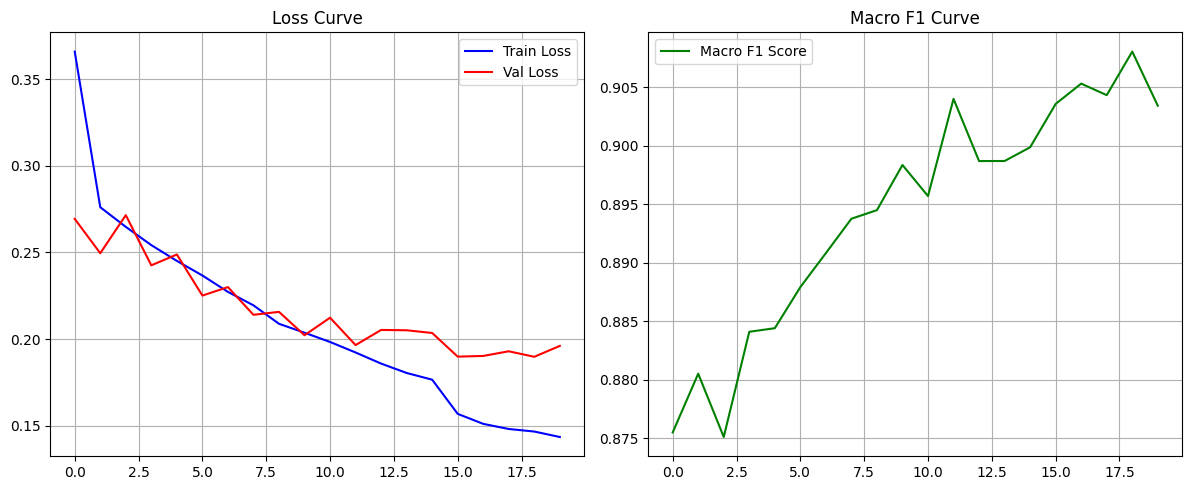


Training LSTM → LSTM - Extreme Skip-gram (Max 20 epochs)


f:\CSE440\dl_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  1/20 | Train Loss: 0.4268 | Val Loss: 0.3141 | Acc: 0.8950 | Macro F1: 0.8587
Epoch  2/20 | Train Loss: 0.3267 | Val Loss: 0.3040 | Acc: 0.8976 | Macro F1: 0.8609
Epoch  3/20 | Train Loss: 0.3138 | Val Loss: 0.2954 | Acc: 0.9015 | Macro F1: 0.8647
Epoch  4/20 | Train Loss: 0.3024 | Val Loss: 0.2833 | Acc: 0.9068 | Macro F1: 0.8715
Epoch  5/20 | Train Loss: 0.2939 | Val Loss: 0.2968 | Acc: 0.9041 | Macro F1: 0.8639
Epoch  6/20 | Train Loss: 0.2849 | Val Loss: 0.2709 | Acc: 0.9101 | Macro F1: 0.8735
Epoch  7/20 | Train Loss: 0.2783 | Val Loss: 0.2833 | Acc: 0.9105 | Macro F1: 0.8724
Epoch  8/20 | Train Loss: 0.2678 | Val Loss: 0.2667 | Acc: 0.9160 | Macro F1: 0.8813
Epoch  9/20 | Train Loss: 0.2601 | Val Loss: 0.2759 | Acc: 0.9073 | Macro F1: 0.8683
Epoch 10/20 | Train Loss: 0.2513 | Val Loss: 0.2586 | Acc: 0.9130 | Macro F1: 0.8793
Epoch 11/20 | Train Loss: 0.2467 | Val Loss: 0.2704 | Acc: 0.9095 | Macro F1: 0.8733
Epoch 12/20 | Train Loss: 0.2406 | Val Loss: 0.2534 | Acc: 0.9175

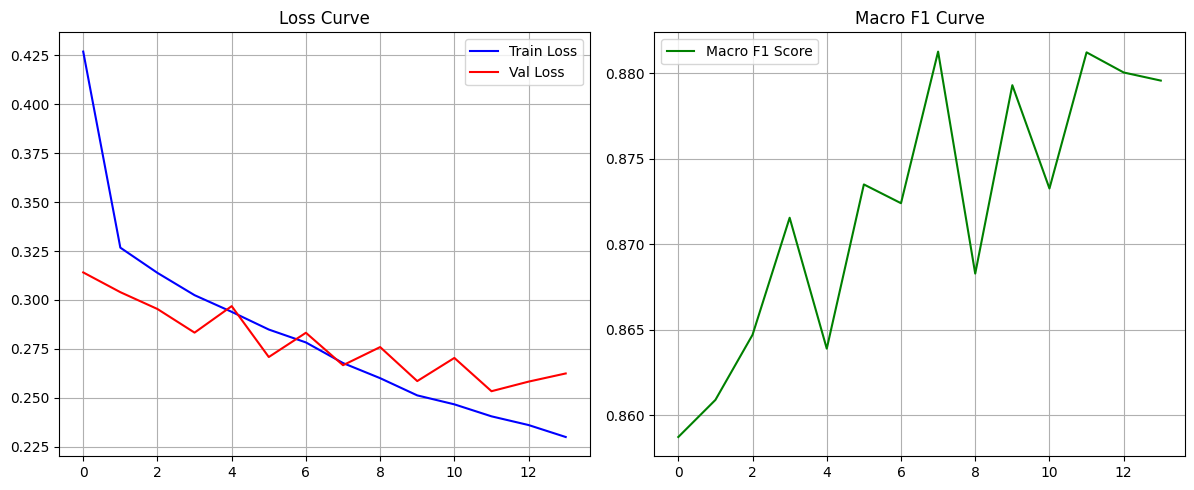


Training LSTM → LSTM - Optimum Skip-gram (Max 20 epochs)


f:\CSE440\dl_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch  1/20 | Train Loss: 0.3658 | Val Loss: 0.2696 | Acc: 0.9120 | Macro F1: 0.8775
Epoch  2/20 | Train Loss: 0.2777 | Val Loss: 0.2430 | Acc: 0.9216 | Macro F1: 0.8893
Epoch  3/20 | Train Loss: 0.2615 | Val Loss: 0.2393 | Acc: 0.9234 | Macro F1: 0.8930
Epoch  4/20 | Train Loss: 0.2516 | Val Loss: 0.2380 | Acc: 0.9247 | Macro F1: 0.8950
Epoch  5/20 | Train Loss: 0.2458 | Val Loss: 0.2367 | Acc: 0.9245 | Macro F1: 0.8942
Epoch  6/20 | Train Loss: 0.2367 | Val Loss: 0.2267 | Acc: 0.9268 | Macro F1: 0.8966
Epoch  7/20 | Train Loss: 0.2278 | Val Loss: 0.2184 | Acc: 0.9280 | Macro F1: 0.8992
Epoch  8/20 | Train Loss: 0.2177 | Val Loss: 0.2176 | Acc: 0.9316 | Macro F1: 0.9029
Epoch  9/20 | Train Loss: 0.2109 | Val Loss: 0.2096 | Acc: 0.9303 | Macro F1: 0.9015
Epoch 10/20 | Train Loss: 0.2017 | Val Loss: 0.2159 | Acc: 0.9305 | Macro F1: 0.8999
Epoch 11/20 | Train Loss: 0.1954 | Val Loss: 0.2089 | Acc: 0.9316 | Macro F1: 0.9033
Epoch 12/20 | Train Loss: 0.1886 | Val Loss: 0.2015 | Acc: 0.9346

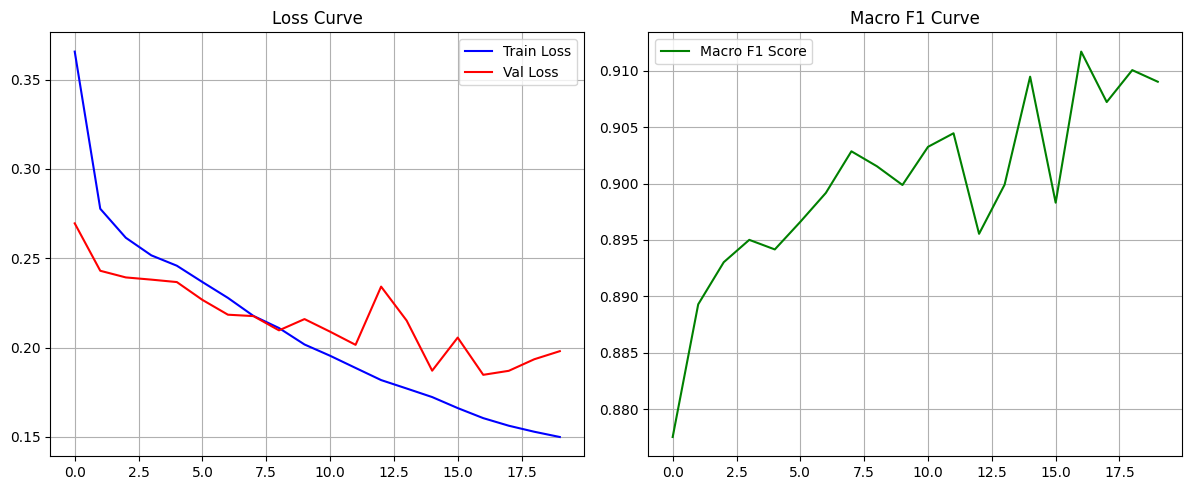


LSTM Training Completed for All Three Versions!


In [70]:
print(" LSTM Training on All 3 Versions...\n")

# ====================== 1. RAW ======================
lstm_raw_uni, f1_raw_uni = train_lstm(
    X_train_raw_seq, X_val_raw_seq, y_train, y_val, 
    name="LSTM - Raw Skip-gram"
)

# ====================== 2. EXTREME ======================
lstm_ex_uni, f1_ex_uni = train_lstm(
    X_train_ex_seq, X_val_ex_seq, y_train, y_val, 
    name="LSTM - Extreme Skip-gram"
)

# ====================== 3. OPTIMUM ======================
lstm_op_uni, f1_op_uni = train_lstm(
    X_train_op_seq, X_val_op_seq, y_train, y_val, 
    name="LSTM - Optimum Skip-gram"
)

print("\nLSTM Training Completed for All Three Versions!")

In [71]:
print(lstm_raw_uni)
print(f1_raw_uni)

OptimizedLSTM(
  (lstm): LSTM(300, 256, num_layers=3, batch_first=True, dropout=0.6)
  (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (dropout1): Dropout(p=0.6, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)
0.9080678598950139


# **Parameter tuning Bi-LSTM**

In [72]:
# ========================= IMPROVED BIDIRECTIONAL LSTM =========================
class tunedBiLSTM(nn.Module):
    def __init__(self, input_size=300, hidden_size=384, num_layers=4, 
                 num_classes=4, dropout=0.55):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.layer_norm = nn.LayerNorm(hidden_size * 2)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(0.45)
        
        # Smaller classifier head for better generalization
        self.fc1 = nn.Linear(hidden_size * 2, 192)
        self.fc2 = nn.Linear(192, num_classes)
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)                  # (batch, seq_len, hidden*2)
        out = lstm_out.mean(dim=1)                  # Mean pooling
        out = self.layer_norm(out)
        out = self.dropout1(out)
        out = torch.relu(self.fc1(out))
        out = self.dropout2(out)
        out = self.fc2(out)
        return out

In [73]:
def train_tuned_bilstm(X_train_seq, X_val_seq, y_train, y_val, name, epochs=18):
    print(f"\n{'='*90}")
    print(f"Training Tuned BiLSTM → {name}")
    print(f"{'='*90}")

    X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val_seq, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_val_t   = torch.tensor(y_val, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)

    model = tunedBiLSTM(dropout=0.55)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0004, weight_decay=1e-5)   # lighter weight decay than the earlier 1e-4 models
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    best_f1 = 0.0
    best_acc = 0.0
    patience_counter = 0
    best_model_state = None

    train_losses, val_losses, val_f1s = [], [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            outputs = model(bx)
            loss = criterion(outputs, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        y_true, y_pred = [], []
        val_loss = 0.0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                outputs = model(bx)
                loss = criterion(outputs, by)
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                y_true.extend(by.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        val_loss /= len(val_loader)
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')
        cm = confusion_matrix(y_true, y_pred)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_f1s.append(f1)

        scheduler.step(val_loss)

        print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Acc: {acc:.4f} | Macro F1: {f1:.4f}")

        if f1 > best_f1 + 0.001:
            best_f1 = f1
            best_acc = acc
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 5:
                print(f" Early stopping triggered at epoch {epoch+1}")
                break

    model.load_state_dict(best_model_state)
    print(f"Best Accuracy : {best_acc:.4f}")
    print(f"\nBest Macro F1: {best_f1:.4f}")
    print(classification_report(y_true, y_pred, digits=4))
    print("\nConfusion Matrix:")
    print(cm)

    # Plot
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title('Loss Curve')
    plt.legend()
    plt.grid()

    plt.subplot(1, 3, 2)
    plt.plot(val_f1s, label='Macro F1')
    plt.title('Macro F1 Curve')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

    return model, best_f1


Training Tuned BiLSTM → BiLSTM - Raw Skip-gram
Epoch  1/18 | Train Loss: 0.3417 | Val Loss: 0.2626 | Acc: 0.9160 | Macro F1: 0.8826
Epoch  2/18 | Train Loss: 0.2618 | Val Loss: 0.2532 | Acc: 0.9202 | Macro F1: 0.8875
Epoch  3/18 | Train Loss: 0.2402 | Val Loss: 0.2253 | Acc: 0.9216 | Macro F1: 0.8862
Epoch  4/18 | Train Loss: 0.2230 | Val Loss: 0.2091 | Acc: 0.9257 | Macro F1: 0.8941
Epoch  5/18 | Train Loss: 0.2104 | Val Loss: 0.2112 | Acc: 0.9269 | Macro F1: 0.8942
Epoch  6/18 | Train Loss: 0.1965 | Val Loss: 0.1996 | Acc: 0.9313 | Macro F1: 0.9003
Epoch  7/18 | Train Loss: 0.1844 | Val Loss: 0.1987 | Acc: 0.9319 | Macro F1: 0.9023
Epoch  8/18 | Train Loss: 0.1724 | Val Loss: 0.1863 | Acc: 0.9358 | Macro F1: 0.9052
Epoch  9/18 | Train Loss: 0.1646 | Val Loss: 0.1915 | Acc: 0.9309 | Macro F1: 0.8952
Epoch 10/18 | Train Loss: 0.1549 | Val Loss: 0.1850 | Acc: 0.9411 | Macro F1: 0.9100
Epoch 11/18 | Train Loss: 0.1436 | Val Loss: 0.1975 | Acc: 0.9412 | Macro F1: 0.9095
Epoch 12/18 | Tra

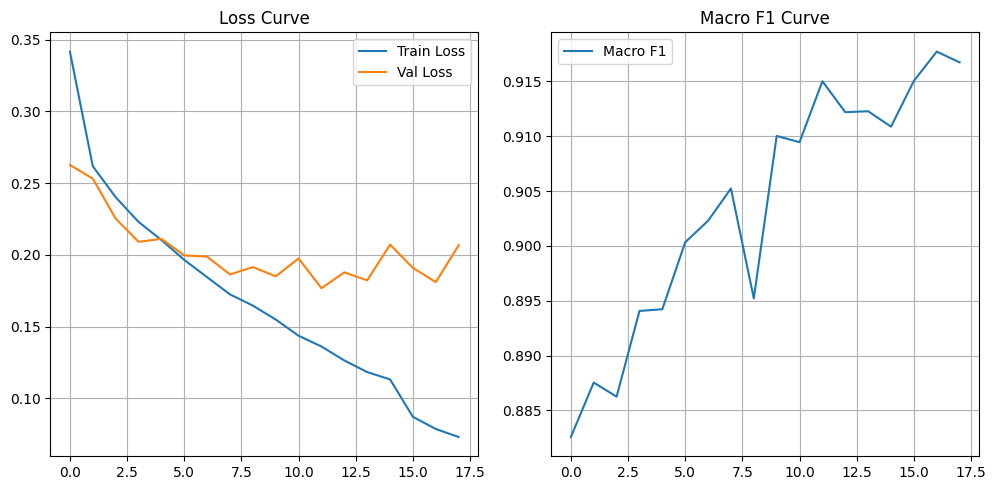


Training Tuned BiLSTM → BiLSTM - Extreme Skip-gram
Epoch  1/18 | Train Loss: 0.4166 | Val Loss: 0.3115 | Acc: 0.8976 | Macro F1: 0.8603
Epoch  2/18 | Train Loss: 0.3149 | Val Loss: 0.3222 | Acc: 0.8971 | Macro F1: 0.8634
Epoch  3/18 | Train Loss: 0.2943 | Val Loss: 0.2986 | Acc: 0.9027 | Macro F1: 0.8635
Epoch  4/18 | Train Loss: 0.2750 | Val Loss: 0.2627 | Acc: 0.9138 | Macro F1: 0.8809
Epoch  5/18 | Train Loss: 0.2623 | Val Loss: 0.2682 | Acc: 0.9148 | Macro F1: 0.8807
Epoch  6/18 | Train Loss: 0.2465 | Val Loss: 0.2515 | Acc: 0.9185 | Macro F1: 0.8846
Epoch  7/18 | Train Loss: 0.2358 | Val Loss: 0.2590 | Acc: 0.9174 | Macro F1: 0.8837
Epoch  8/18 | Train Loss: 0.2209 | Val Loss: 0.2602 | Acc: 0.9156 | Macro F1: 0.8814
Epoch  9/18 | Train Loss: 0.2089 | Val Loss: 0.2456 | Acc: 0.9218 | Macro F1: 0.8856
Epoch 10/18 | Train Loss: 0.1975 | Val Loss: 0.2375 | Acc: 0.9231 | Macro F1: 0.8912
Epoch 11/18 | Train Loss: 0.1830 | Val Loss: 0.2369 | Acc: 0.9267 | Macro F1: 0.8925
Epoch 12/18 |

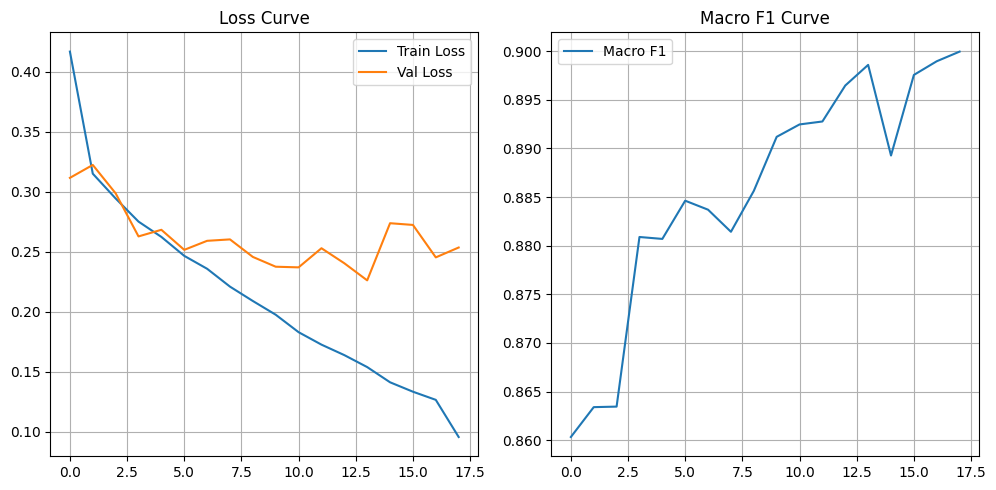


Training Tuned BiLSTM → Improved BiLSTM - Optimum Skip-gram
Epoch  1/18 | Train Loss: 0.3514 | Val Loss: 0.3040 | Acc: 0.8952 | Macro F1: 0.8592
Epoch  2/18 | Train Loss: 0.2642 | Val Loss: 0.2470 | Acc: 0.9228 | Macro F1: 0.8902
Epoch  3/18 | Train Loss: 0.2448 | Val Loss: 0.2523 | Acc: 0.9253 | Macro F1: 0.8959
Epoch  4/18 | Train Loss: 0.2301 | Val Loss: 0.2492 | Acc: 0.9229 | Macro F1: 0.8874
Epoch  5/18 | Train Loss: 0.2143 | Val Loss: 0.2084 | Acc: 0.9325 | Macro F1: 0.9035
Epoch  6/18 | Train Loss: 0.2009 | Val Loss: 0.2004 | Acc: 0.9321 | Macro F1: 0.9027
Epoch  7/18 | Train Loss: 0.1879 | Val Loss: 0.1981 | Acc: 0.9370 | Macro F1: 0.9090
Epoch  8/18 | Train Loss: 0.1757 | Val Loss: 0.2011 | Acc: 0.9371 | Macro F1: 0.9077
Epoch  9/18 | Train Loss: 0.1633 | Val Loss: 0.2353 | Acc: 0.9250 | Macro F1: 0.8838
Epoch 10/18 | Train Loss: 0.1541 | Val Loss: 0.1757 | Acc: 0.9428 | Macro F1: 0.9152
Epoch 11/18 | Train Loss: 0.1431 | Val Loss: 0.2079 | Acc: 0.9424 | Macro F1: 0.9141
Epoc

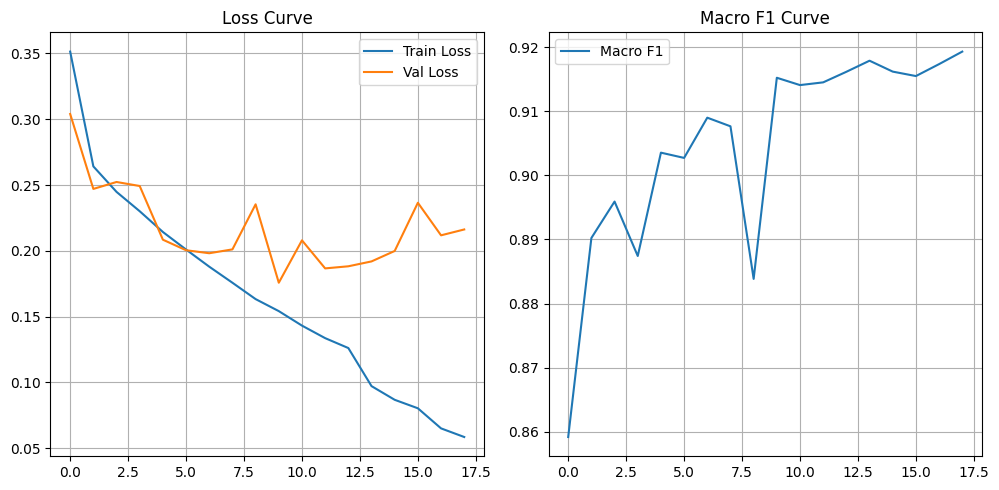

In [74]:
# Train on Optimum (your best version)
bilstm_raw_tuned, f1_raw_tuned = train_tuned_bilstm(
    X_train_raw_seq, X_val_raw_seq, y_train, y_val, 
    name="BiLSTM - Raw Skip-gram"
)

# ====================== 2. EXTREME ======================
bilstm_ex_tuned, f1_ex_tuned = train_tuned_bilstm(
    X_train_ex_seq, X_val_ex_seq, y_train, y_val, 
    name="BiLSTM - Extreme Skip-gram"
)
bilstm_op_tuned, f1_op_tuned = train_tuned_bilstm(
    X_train_op_seq, X_val_op_seq, y_train, y_val, 
    name="Improved BiLSTM - Optimum Skip-gram"
)

The hidden size was increased to 384 and layers to 4 to improve the model’s ability to capture complex and long-range dependencies in the sequence. Since LSTM can effectively utilize deeper representations, increasing capacity helped improve feature learning.

To prevent overfitting from the larger model, dropout was increased to 0.55 (and 0.45) and weight decay (1e-5) was applied. This stronger regularization was necessary as deeper BiLSTM models tend to memorize patterns.

The classifier head was kept relatively smaller (768 → 192 → output) to avoid excessive parameters after the already rich bidirectional LSTM representation, improving generalization.

The learning rate was set to 0.0004 to balance convergence speed and stability, as higher values caused fluctuations while lower values slowed training.

# **Simple RNN with perameter tuning**

In [75]:
######## RNN Tuning and Training ########
    
class revisedRNN(nn.Module):
    def __init__(self, input_size=300, hidden_size=384, num_layers=3, 
                 num_classes=4, dropout=0.4):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc1 = nn.Linear(hidden_size, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, num_classes)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        rnn_out, _ = self.rnn(x)

        out = rnn_out.mean(dim=1)

        out = torch.relu(self.fc1(out))
        out = self.dropout(out)

        out = torch.relu(self.fc2(out))
        out = self.dropout(out)

        out = torch.relu(self.fc3(out))
        out = self.dropout(out)

        out = self.fc4(out)

        return out

def train_revised_simplernn(X_train_seq, X_val_seq, y_train, y_val, name, epochs=18):
    print(f"\n{'='*90}")
    print(f"Training Revised SimpleRNN → {name}")
    print(f"{'='*90}")

    X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val_seq,   dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_val_t   = torch.tensor(y_val,   dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=64, shuffle=False)

    model = revisedRNN(dropout=0.5)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    #optimizer = torch.optim.AdamW(    model.parameters(),    lr=0.0007,    weight_decay=5e-5)
    optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    best_f1 = 0.0
    patience_counter = 0
    best_model_state = None

    train_losses, val_losses, val_f1s = [], [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            outputs = model(bx)
            loss = criterion(outputs, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        y_true, y_pred = [], []
        val_loss = 0.0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                outputs = model(bx)
                loss = criterion(outputs, by)
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                y_true.extend(by.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        val_loss /= len(val_loader)
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro')
        cm = confusion_matrix(y_true, y_pred)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_f1s.append(f1)

        scheduler.step(val_loss)

        print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Acc: {acc:.4f} | Macro F1: {f1:.4f}")

        if f1 > best_f1 + 0.002:
            best_f1 = f1
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 6:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    model.load_state_dict(best_model_state)

    print(f"\nFinal Results - {name}")
    print(f"Final Accuracy : {acc:.4f}")
    print(f"Best Macro F1 : {best_f1:.4f}")
    print(classification_report(y_true, y_pred, digits=4))
    print("\nConfusion Matrix:")
    print(cm)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title('Loss Curve')
    plt.legend()
    plt.grid()

    plt.subplot(1, 3, 2)
    plt.plot(val_f1s, label='Macro F1')
    plt.title('Macro F1 Curve')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

    return model, best_f1

=== Raw ===

Training Revised SimpleRNN → SimpleRNN - Raw Skip-gram
Epoch  1/18 | Train Loss: 0.6606 | Val Loss: 0.3386 | Acc: 0.8817 | Macro F1: 0.8277
Epoch  2/18 | Train Loss: 0.3366 | Val Loss: 0.3198 | Acc: 0.8929 | Macro F1: 0.8506
Epoch  3/18 | Train Loss: 0.3015 | Val Loss: 0.2794 | Acc: 0.9099 | Macro F1: 0.8751
Epoch  4/18 | Train Loss: 0.2776 | Val Loss: 0.2591 | Acc: 0.9131 | Macro F1: 0.8779
Epoch  5/18 | Train Loss: 0.2694 | Val Loss: 0.2513 | Acc: 0.9146 | Macro F1: 0.8809
Epoch  6/18 | Train Loss: 0.2629 | Val Loss: 0.2519 | Acc: 0.9158 | Macro F1: 0.8820
Epoch  7/18 | Train Loss: 0.2598 | Val Loss: 0.2412 | Acc: 0.9183 | Macro F1: 0.8843
Epoch  8/18 | Train Loss: 0.2546 | Val Loss: 0.2509 | Acc: 0.9169 | Macro F1: 0.8821
Epoch  9/18 | Train Loss: 0.2502 | Val Loss: 0.2500 | Acc: 0.9139 | Macro F1: 0.8796
Epoch 10/18 | Train Loss: 0.2472 | Val Loss: 0.2468 | Acc: 0.9152 | Macro F1: 0.8806
Epoch 11/18 | Train Loss: 0.2308 | Val Loss: 0.2328 | Acc: 0.9213 | Macro F1: 0.88

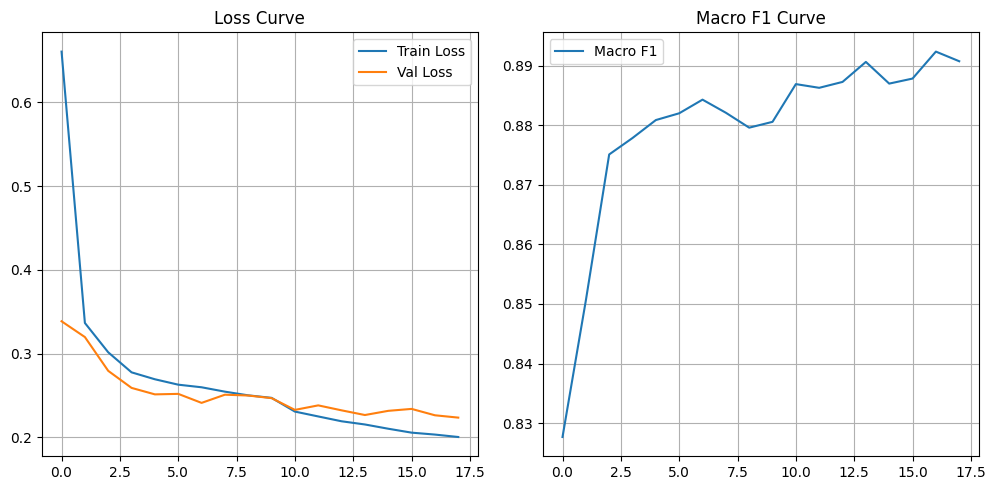


=== Extreme ===

Training Revised SimpleRNN → SimpleRNN - Extreme Skip-gram
Epoch  1/18 | Train Loss: 0.6470 | Val Loss: 0.4566 | Acc: 0.8285 | Macro F1: 0.7491
Epoch  2/18 | Train Loss: 0.4055 | Val Loss: 0.3687 | Acc: 0.8773 | Macro F1: 0.8282
Epoch  3/18 | Train Loss: 0.3831 | Val Loss: 0.3406 | Acc: 0.8921 | Macro F1: 0.8531
Epoch  4/18 | Train Loss: 0.3449 | Val Loss: 0.3297 | Acc: 0.8924 | Macro F1: 0.8518
Epoch  5/18 | Train Loss: 0.3336 | Val Loss: 0.3280 | Acc: 0.8910 | Macro F1: 0.8537
Epoch  6/18 | Train Loss: 0.3289 | Val Loss: 0.3084 | Acc: 0.8990 | Macro F1: 0.8594
Epoch  7/18 | Train Loss: 0.3214 | Val Loss: 0.3226 | Acc: 0.8964 | Macro F1: 0.8592
Epoch  8/18 | Train Loss: 0.3138 | Val Loss: 0.3045 | Acc: 0.9018 | Macro F1: 0.8657
Epoch  9/18 | Train Loss: 0.3105 | Val Loss: 0.3111 | Acc: 0.8971 | Macro F1: 0.8556
Epoch 10/18 | Train Loss: 0.3066 | Val Loss: 0.2955 | Acc: 0.9013 | Macro F1: 0.8653
Epoch 11/18 | Train Loss: 0.3021 | Val Loss: 0.3042 | Acc: 0.8978 | Macro

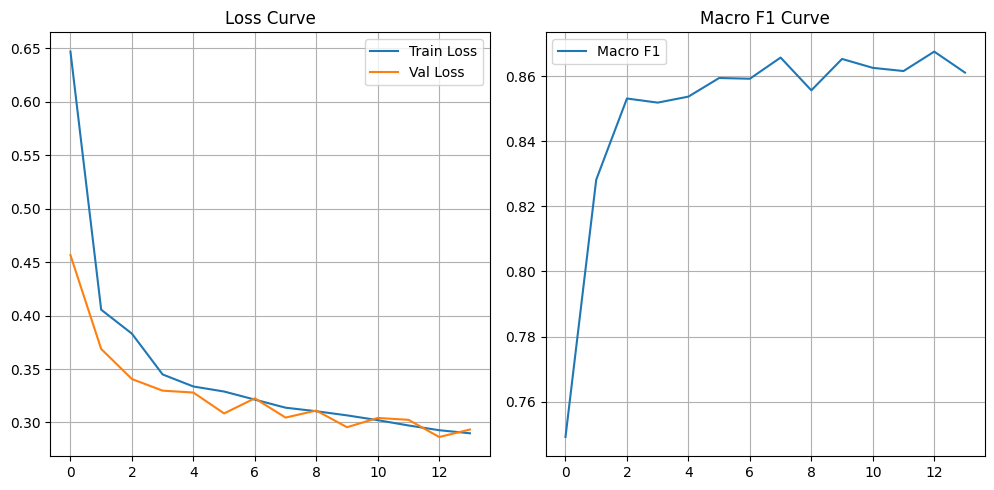


=== Optimum ===

Training Revised SimpleRNN → SimpleRNN - Optimum Skip-gram
Epoch  1/18 | Train Loss: 0.5378 | Val Loss: 0.3436 | Acc: 0.8897 | Macro F1: 0.8405
Epoch  2/18 | Train Loss: 0.3419 | Val Loss: 0.3246 | Acc: 0.8987 | Macro F1: 0.8588
Epoch  3/18 | Train Loss: 0.3068 | Val Loss: 0.2757 | Acc: 0.9121 | Macro F1: 0.8762
Epoch  4/18 | Train Loss: 0.2860 | Val Loss: 0.2777 | Acc: 0.9058 | Macro F1: 0.8690
Epoch  5/18 | Train Loss: 0.2780 | Val Loss: 0.2619 | Acc: 0.9121 | Macro F1: 0.8783
Epoch  6/18 | Train Loss: 0.2704 | Val Loss: 0.2780 | Acc: 0.9094 | Macro F1: 0.8715
Epoch  7/18 | Train Loss: 0.2657 | Val Loss: 0.2522 | Acc: 0.9173 | Macro F1: 0.8859
Epoch  8/18 | Train Loss: 0.2599 | Val Loss: 0.2458 | Acc: 0.9178 | Macro F1: 0.8853
Epoch  9/18 | Train Loss: 0.2532 | Val Loss: 0.2485 | Acc: 0.9169 | Macro F1: 0.8857
Epoch 10/18 | Train Loss: 0.2510 | Val Loss: 0.2373 | Acc: 0.9185 | Macro F1: 0.8871
Epoch 11/18 | Train Loss: 0.2464 | Val Loss: 0.2320 | Acc: 0.9205 | Macro

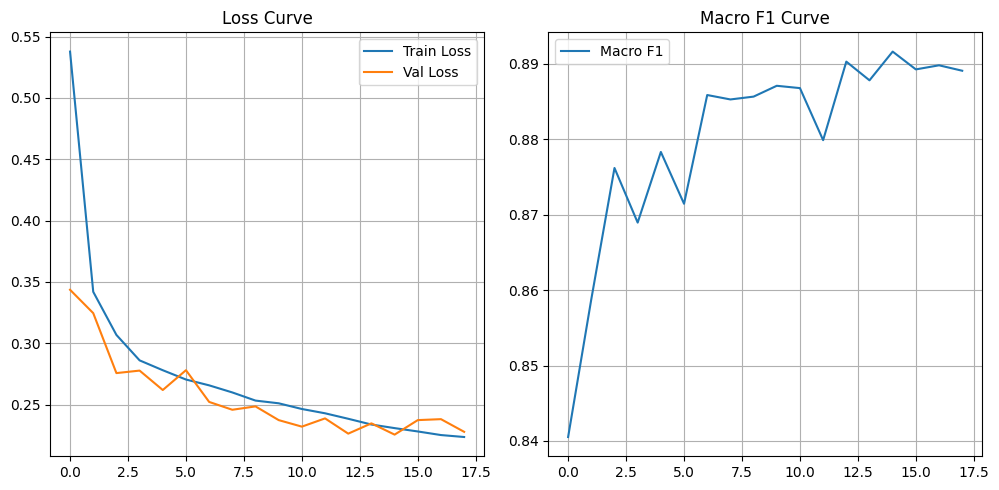

In [76]:
# Train the optimized SimpleRNN
print("=== Raw ===")
rnn_raw_Tuned, f1_raw = train_revised_simplernn(X_train_raw_seq, X_val_raw_seq, y_train, y_val, "SimpleRNN - Raw Skip-gram")

print("\n=== Extreme ===")
rnn_ex_Tuned, f1_ex = train_revised_simplernn(X_train_ex_seq, X_val_ex_seq, y_train, y_val, "SimpleRNN - Extreme Skip-gram")

print("\n=== Optimum ===")
rnn_op_Tuned, f1_op = train_revised_simplernn(X_train_op_seq, X_val_op_seq, y_train, y_val, "SimpleRNN - Optimum Skip-gram")

The hidden size was increased from 256 to 384 to enhance the model’s capacity to capture more complex sequential patterns from the embeddings. The earlier configuration showed limited representation power, so increasing the hidden dimension improved feature learning.

The classifier was deepened to a multi-layer structure (384→512→256→128→C) to allow gradual feature transformation instead of directly mapping to output. This helps the model learn more refined decision boundaries and improves classification performance.

Since the larger model introduced a higher risk of overfitting, dropout was decresed to 0.5 to monitor the performance.

The learning rate was reduced (0.0005 → 0.0003) to ensure stable training, as larger models are more sensitive to parameter updates.

In [77]:
# ========================= PyTorch DNN TRAINING FUNCTION =========================
def train_dnn_model(X_train, X_val, y_train, y_val, name, epochs=12, batch_size=64):
    print(f"\n{'='*60}")
    print(f"Training DNN (PyTorch) → {name}")
    print(f"{'='*60}")

    # Convert to PyTorch tensors
    X_train_t = torch.tensor(X_train.toarray(), dtype=torch.float32) if hasattr(X_train, 'toarray') else torch.tensor(X_train, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val.toarray(),   dtype=torch.float32) if hasattr(X_val, 'toarray')   else torch.tensor(X_val, dtype=torch.float32)
    
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    y_val_t   = torch.tensor(y_val,   dtype=torch.long)

    # Create DataLoaders
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset   = TensorDataset(X_val_t, y_val_t)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

    # Define the model (same architecture as before)
    class DNN(nn.Module):
        def __init__(self, input_dim, num_classes):
            super().__init__()
            self.model = nn.Sequential(
                nn.Linear(input_dim, 512),
                nn.BatchNorm1d(512),
                nn.ReLU(),
                nn.Dropout(0.2),

                nn.Linear(512, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(0.3),

                nn.Linear(256, 128),
                nn.ReLU(),

                nn.Linear(128, num_classes)
            )

        
        def forward(self, x):
            return self.model(x)

    model = DNN(X_train_t.shape[1], num_classes)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.003)

    # Training loop
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()




        y_true, y_pred = [], []
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(device)
                outputs = model(batch_x)
                preds = torch.argmax(outputs, dim=1)
                y_true.extend(batch_y.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())
        
        acc = accuracy_score(y_true, y_pred)
        f1_macro = f1_score(y_true, y_pred, average='macro')
        cm = confusion_matrix(y_true, y_pred)
   
        
        print(f"Epoch {epoch+1}/{epochs} - Val Accuracy: {acc:.4f} - Val Macro F1: {f1_macro:.4f}")
    

    # Final evaluation
    print(f"\nFinal Results for {name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1 Macro : {f1_macro:.4f}")
    print(classification_report(y_true, y_pred))
    print("\nConfusion Matrix:")
    print(cm)
    

    return model, acc, f1_macro


In [78]:
# Train on all three TF-IDF versions

# RAW
dnnRaw_Tuned, acc1, f11 = train_dnn_model(
    X_train_raw_tfidf, X_val_raw_tfidf,
    y_train, y_val,
    "DNN TF-IDF Raw"
)

# EXTREME
dnnEx_Tuned, acc2, f12 = train_dnn_model(
    X_train_ex_tfidf, X_val_ex_tfidf,
    y_train, y_val,
    "DNN TF-IDF Extreme"
)

# OPTIMAL
dnnOp_Tuned, acc3, f13 = train_dnn_model(
    X_train_op_tfidf, X_val_op_tfidf,
    y_train, y_val,
    "DNN TF-IDF Optimal"
)


Training DNN (PyTorch) → DNN TF-IDF Raw


Epoch 1/12 - Val Accuracy: 0.9359 - Val Macro F1: 0.9064
Epoch 2/12 - Val Accuracy: 0.9399 - Val Macro F1: 0.9089
Epoch 3/12 - Val Accuracy: 0.9422 - Val Macro F1: 0.9102
Epoch 4/12 - Val Accuracy: 0.9390 - Val Macro F1: 0.9051
Epoch 5/12 - Val Accuracy: 0.9399 - Val Macro F1: 0.9069
Epoch 6/12 - Val Accuracy: 0.9415 - Val Macro F1: 0.9088
Epoch 7/12 - Val Accuracy: 0.9426 - Val Macro F1: 0.9102
Epoch 8/12 - Val Accuracy: 0.9443 - Val Macro F1: 0.9125
Epoch 9/12 - Val Accuracy: 0.9431 - Val Macro F1: 0.9107
Epoch 10/12 - Val Accuracy: 0.9453 - Val Macro F1: 0.9139
Epoch 11/12 - Val Accuracy: 0.9421 - Val Macro F1: 0.9087
Epoch 12/12 - Val Accuracy: 0.9436 - Val Macro F1: 0.9116

Final Results for DNN TF-IDF Raw
Accuracy : 0.9436
F1 Macro : 0.9116
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      2360
           1       0.86      0.82      0.84      1949
           2       0.98      0.99      0.98      7134
           3       0.96   

# Training Comparision

The architecture was expanded to 512 → 256 → 128 → output to increase the model’s capacity to learn complex patterns from high-dimensional TF-IDF features. A larger first layer (512) helps capture diverse feature interactions, while subsequent layers gradually reduce dimensionality to form more compact representations.

Batch normalization was introduced after the first two layers to stabilize training and improve convergence by reducing internal covariate shift. This also allows the model to train effectively with a relatively higher learning rate.

Dropout (0.2, 0.3) was applied to reduce overfitting, with lower values in earlier layers to preserve information and slightly higher dropout in deeper layers for stronger regularization.

The learning rate was increased to 0.003 to speed up convergence, supported by batch normalization which stabilizes updates. Lower learning rates slowed training without improving performance.

A batch size of 64 was chosen to balance computational efficiency and stable gradient updates, and 12 epochs were sufficient as validation performance stabilized within this range.

# *Testing*

In [83]:
#####################################           TESTING ALL LOGISTIC REGRESSION MODELS            #####################################
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np

# ====================== PREPARE y_test CORRECTLY ======================
y_test = test["News Topic"].copy()   

label_map = {
    "Business": 0,
    "Science and Technology": 1,
    "Sports": 2,
    "World News": 3
}

# Apply mapping safely
y_test_numeric = y_test.map(label_map)

# Check for any missing mappings (very important!)
if y_test_numeric.isnull().any():
    print("  WARNING: Some labels in test set were not mapped!")
    print("Unmapped values:", y_test[y_test_numeric.isnull()].unique())
    # Drop unmapped rows if any
    valid_indices = y_test_numeric.notna()
    y_test_numeric = y_test_numeric[valid_indices]
    # You'll also need to filter X_test accordingly in the test function
else:
    print(" All test labels mapped successfully.")

y_test = y_test_numeric.astype(int)   # ensure integer type

def test_lr_model(model, X_test, y_test, name):
    print(f"\n{'='*70}")
    print(f"Testing Logistic Regression → {name}")
    print(f"{'='*70}")
    
    y_pred = model.predict(X_test)
    
    # ========= FIX: Convert predictions to numeric if they're strings =========
    if isinstance(y_pred[0], str):
        # Create reverse mapping
        reverse_label_map = {v: k for k, v in label_map.items()}
        # Map predictions from strings to integers
        y_pred_numeric = np.array([label_map[pred] for pred in y_pred])
    else:
        y_pred_numeric = y_pred
    
    # Now both are numeric
    acc = accuracy_score(y_test, y_pred_numeric)
    f1_macro = f1_score(y_test, y_pred_numeric, average="macro")
    cm = confusion_matrix(y_test, y_pred_numeric)
    
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {f1_macro:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_numeric, digits=4, 
                                target_names=list(label_map.keys())))
    print("\nConfusion Matrix:")
    print(cm)
    
    return acc, f1_macro

# ========================= RUN TEST ON ALL 3 MODELS =========================
# 1. TF-IDF Raw
acc1, f11 = test_lr_model(logregTFIDFraw, X_test_raw_tfidf, y_test, "TF-IDF Raw")

# 2. TF-IDF Extreme
acc2, f12 = test_lr_model(logregTFIDFextreme, X_test_ex_tfidf, y_test, "TF-IDF Extreme")

# 3. TF-IDF Optimum
acc3, f13 = test_lr_model(logregTFIDFoptimum, X_test_op_tfidf, y_test, "TF-IDF Optimum")

print("\n" + "="*60)
print("FINAL LOGISTIC REGRESSION TEST RESULTS")
print("="*60)
print(f"TF-IDF Raw      → Acc: {acc1:.4f} | Macro F1: {f11:.4f}")
print(f"TF-IDF Extreme  → Acc: {acc2:.4f} | Macro F1: {f12:.4f}")
print(f"TF-IDF Optimum  → Acc: {acc3:.4f} | Macro F1: {f13:.4f}")

 All test labels mapped successfully.

Testing Logistic Regression → TF-IDF Raw
Accuracy : 0.9074
Macro F1 : 0.9065

Classification Report:
                        precision    recall  f1-score   support

              Business     0.9276    0.8113    0.8656      3000
                Sports     0.9339    0.9893    0.9608      3000
Science and Technology     0.8720    0.9083    0.8898      3000
            World News     0.8988    0.9207    0.9096      3000

              accuracy                         0.9074     12000
             macro avg     0.9081    0.9074    0.9065     12000
          weighted avg     0.9081    0.9074    0.9065     12000


Confusion Matrix:
[[2434   65  321  180]
 [   4 2968    9   19]
 [ 114   49 2725  112]
 [  72   96   70 2762]]

Testing Logistic Regression → TF-IDF Extreme
Accuracy : 0.9016
Macro F1 : 0.9007

Classification Report:
                        precision    recall  f1-score   support

              Business     0.8922    0.8523    0.8718      300

In [84]:
# ========================= TEST DNN MODELS =========================

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import torch
import numpy as np

# ====================== PREPARE y_test CORRECTLY ======================
y_test = test["News Topic"].copy()   # original column

label_map = {
    "Business": 0,
    "Science and Technology": 1,
    "Sports": 2,
    "World News": 3
}

# Apply mapping safely
y_test_numeric = y_test.map(label_map)

# Check for any missing mappings
if y_test_numeric.isnull().any():
    print("  WARNING: Some labels in test set were not mapped!")
    print("Unmapped values:", y_test[y_test_numeric.isnull()].unique())
else:
    print(" All test labels mapped successfully.")

y_test = y_test_numeric.astype(int)   # ensure integer type


# ========================= DNN TEST FUNCTION =========================
def test_dnn_model(model, X_test, y_test, name, batch_size=32):
    print(f"\n{'='*70}")
    print(f"Testing DNN (PyTorch) → {name}")
    print(f"{'='*70}")
    
    # Convert to PyTorch tensors
    X_test_t = torch.tensor(X_test.toarray(), dtype=torch.float32) if hasattr(X_test, 'toarray') else torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.long)
    
    # Create DataLoader
    test_dataset = TensorDataset(X_test_t, y_test_t)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()  # Set to evaluation mode
    
    # Predictions
    y_true, y_pred = [], []
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            preds = torch.argmax(outputs, dim=1)
            
            y_true.extend(batch_y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    
    # Convert to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Calculate metrics
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {f1_macro:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4, 
                                target_names=list(label_map.keys())))
    print("\nConfusion Matrix:")
    print(cm)
    
    return acc, f1_macro


# ========================= RUN TEST ON ALL 3 DNN MODELS =========================
# 1. DNN TF-IDF Raw
acc1_dnn, f11_dnn = test_dnn_model(dnn1_Raw, X_test_raw_tfidf, y_test, "DNN TF-IDF Raw")

# 2. DNN TF-IDF Extreme
acc2_dnn, f12_dnn = test_dnn_model(dnn2_Extreme, X_test_ex_tfidf, y_test, "DNN TF-IDF Extreme")

# 3. DNN TF-IDF Optimum
acc3_dnn, f13_dnn = test_dnn_model(dnn3_Optimal, X_test_op_tfidf, y_test, "DNN TF-IDF Optimum")


# ========================= FINAL SUMMARY =========================
print("\n" + "="*70)
print("FINAL DNN (PyTorch) TEST RESULTS")
print("="*70)
print(f"DNN TF-IDF Raw      → Acc: {acc1_dnn:.4f} | Macro F1: {f11_dnn:.4f}")
print(f"DNN TF-IDF Extreme  → Acc: {acc2_dnn:.4f} | Macro F1: {f12_dnn:.4f}")
print(f"DNN TF-IDF Optimum  → Acc: {acc3_dnn:.4f} | Macro F1: {f13_dnn:.4f}")


# ========================= COMPARISON: LOGISTIC REGRESSION vs DNN =========================
print("\n" + "="*70)
print("COMPARISON: LOGISTIC REGRESSION vs DNN")
print("="*70)
print("\nLogistic Regression Results:")
print(f"  TF-IDF Raw      → Acc: {acc1:.4f} | Macro F1: {f11:.4f}")
print(f"  TF-IDF Extreme  → Acc: {acc2:.4f} | Macro F1: {f12:.4f}")
print(f"  TF-IDF Optimum  → Acc: {acc3:.4f} | Macro F1: {f13:.4f}")

print("\nDNN (PyTorch) Results:")
print(f"  TF-IDF Raw      → Acc: {acc1_dnn:.4f} | Macro F1: {f11_dnn:.4f}")
print(f"  TF-IDF Extreme  → Acc: {acc2_dnn:.4f} | Macro F1: {f12_dnn:.4f}")
print(f"  TF-IDF Optimum  → Acc: {acc3_dnn:.4f} | Macro F1: {f13_dnn:.4f}")

print("\nImprovement (DNN over Logistic Regression):")
print(f"  TF-IDF Raw      → Acc: {(acc1_dnn - acc1)*100:+.2f}% | Macro F1: {(f11_dnn - f11)*100:+.2f}%")
print(f"  TF-IDF Extreme  → Acc: {(acc2_dnn - acc2)*100:+.2f}% | Macro F1: {(f12_dnn - f12)*100:+.2f}%")
print(f"  TF-IDF Optimum  → Acc: {(acc3_dnn - acc3)*100:+.2f}% | Macro F1: {(f13_dnn - f13)*100:+.2f}%")

 All test labels mapped successfully.

Testing DNN (PyTorch) → DNN TF-IDF Raw
Accuracy : 0.4177
Macro F1 : 0.4407

Classification Report:
                        precision    recall  f1-score   support

              Business     0.9307    0.7703    0.8430      3000
                Sports     0.0062    0.0073    0.0067      3000
Science and Technology     0.0109    0.0113    0.0111      3000
            World News     0.9229    0.8817    0.9018      3000

              accuracy                         0.4177     12000
             macro avg     0.4677    0.4177    0.4407     12000
          weighted avg     0.4677    0.4177    0.4407     12000


Confusion Matrix:
[[2311  518   54  117]
 [   4   22 2940   34]
 [  96 2800   34   70]
 [  72  197   86 2645]]

Testing DNN (PyTorch) → DNN TF-IDF Extreme
Accuracy : 0.4541
Macro F1 : 0.4455

Classification Report:
                        precision    recall  f1-score   support

              Business     0.8579    0.8773    0.8675      3000
  

In [80]:
############ Testing  Models ############
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# -------- LABEL MAP --------
label_map = {
    "Business": 0,
    "Science and Technology": 1,
    "Sports": 2,
    "World News": 3
}

y_test = test['News Topic'].map(label_map).values

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def eval_model(model, X, name):
    model.to(device)
    model.eval()

    X_t = torch.tensor(X, dtype=torch.float32).to(device)

    with torch.no_grad():
        y_pred = torch.argmax(model(X_t), dim=1).cpu().numpy()

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')

    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f}")
    print(confusion_matrix(y_test, y_pred))

    return acc, f1


# -------- RUN ALL --------
###############               BiRNN MODELS               ###############
acc_raw1, f1_raw = eval_model(BiRNN_raw, X_test_raw_seq, "RAW BiRNN")
acc_ex1,  f1_ex  = eval_model(BiRNN_ex,  X_test_ex_seq,  "EXTREME BiRNN")
acc_op1,  f1_op  = eval_model(BiRNN_op,  X_test_op_seq,  "OPTIMUM BiRNN")
###############               BiLSTM MODELS               ###############
acc_raw2, f1_raw2 = eval_model(bilstm_raw, X_test_raw_seq, "BiLSTM RAW")
acc_ex2,  f1_ex2  = eval_model(bilstm_ex,  X_test_ex_seq,  "BiLSTM EXTREME")
acc_op2,  f1_op2  = eval_model(bilstm_op,  X_test_op_seq,  "BiLSTM OPTIMUM")    
###############               BiGRU MODELS               ###############
acc_raw3, f1_raw3 = eval_model(BiGRUraw, X_test_raw_seq, "BiGRU RAW")
acc_ex3,  f1_ex3  = eval_model(BiGRUex,  X_test_ex_seq,  "BiGRU EXTREME")
acc_op3,  f1_op3  = eval_model(BiGRUop,  X_test_op_seq,  "BiGRU OPTIMUM")
###############               UNIDIRECTIONAL RNN MODELS               ###############
acc_raw4, f1_raw4 = eval_model(rnn_raw, X_test_raw_seq, "RNN RAW")
acc_ex4,  f1_ex4  = eval_model(rnn_ex,  X_test_ex_seq,  "RNN EXTREME")
acc_op4,  f1_op4  = eval_model(rnn_op,  X_test_op_seq,  "RNN OPTIMUM")
###############               Unidirectional LSTM MODELS               ###############
acc_raw5, f1_raw5 = eval_model(lstm_raw_uni, X_test_raw_seq, "LSTM RAW")
acc_ex5,  f1_ex5  = eval_model(lstm_ex_uni,  X_test_ex_seq,  "LSTM EXTREME")
acc_op5,  f1_op5  = eval_model(lstm_op_uni,  X_test_op_seq,  "LSTM OPTIMUM")
###############              Unidirectional GRU MODELS               ###############
acc_raw6, f1_raw6 = eval_model(gru_raw_uni, X_test_raw_seq, "GRU RAW")
acc_ex6,  f1_ex6  = eval_model(gru_ex_uni,  X_test_ex_seq,  "GRU EXTREME")
acc_op6,  f1_op6  = eval_model(gru_op_uni,  X_test_op_seq,  "GRU OPTIMUM")

###############               Bi-LSTM Tuned               ###############
acc_raw7, f1_raw7 = eval_model(bilstm_raw_tuned, X_test_raw_seq, "BiLSTM RAW TUNED")
acc_ex7,  f1_ex7  = eval_model(bilstm_ex_tuned,  X_test_ex_seq,  "BiLSTM EXTREME TUNED")
acc_op7,  f1_op7  = eval_model(bilstm_op_tuned,  X_test_op_seq,  "BiLSTM OPTIMUM TUNED")
################               RNN Tuned               ###############
acc_raw8, f1_raw8 = eval_model(rnn_raw_Tuned, X_test_raw_seq, "RNN RAW TUNED")  
acc_ex8,  f1_ex8  = eval_model(rnn_ex_Tuned,  X_test_ex_seq,  "RNN EXTREME TUNED")
acc_op8,  f1_op8  = eval_model(rnn_op_Tuned,    X_test_op_seq,  "RNN OPTIMUM TUNED")


# -------- FINAL SUMMARY --------
print("\nFINAL RESULT")
print(f"RAW      → {acc_raw1:.4f} | {f1_raw:.4f}")
print(f"EXTREME  → {acc_ex1:.4f} | {f1_ex:.4f}")
print(f"OPTIMUM  → {acc_op1:.4f} | {f1_op:.4f}")
print("\n" + "="*60)
print(f"BiLSTM RAW      → {acc_raw2:.4f} | {f1_raw2:.4f}")
print(f"BiLSTM EXTREME  → {acc_ex2:.4f} | {f1_ex2:.4f}")
print(f"BiLSTM OPTIMUM  → {acc_op2:.4f} | {f1_op2:.4f}")
print("\n" + "="*60)
print(f"BiGRU RAW      → {acc_raw3:.4f} | {f1_raw3:.4f}")
print(f"BiGRU EXTREME  → {acc_ex3:.4f} | {f1_ex3:.4f}")
print(f"BiGRU OPTIMUM  → {acc_op3:.4f} | {f1_op3:.4f}")
print("\n" + "="*60)
print(f"RNN RAW      → {acc_raw4:.4f} | {f1_raw4:.4f}")
print(f"RNN EXTREME  → {acc_ex4:.4f} | {f1_ex4:.4f}")
print(f"RNN OPTIMUM  → {acc_op4:.4f} | {f1_op4:.4f}")
print("\n" + "="*60)
print(f"LSTM RAW      → {acc_raw5:.4f} | {f1_raw5:.4f}")
print(f"LSTM EXTREME  → {acc_ex5:.4f} | {f1_ex5:.4f}")
print(f"LSTM OPTIMUM  → {acc_op5:.4f} | {f1_op5:.4f}")  
print("\n" + "="*60)
print(f"GRU RAW      → {acc_raw6:.4f} | {f1_raw6:.4f}")     
print(f"GRU EXTREME  → {acc_ex6:.4f} | {f1_ex6:.4f}")
print(f"GRU OPTIMUM  → {acc_op6:.4f} | {f1_op6:.4f}")
print("\n" + "="*60)
print(f"BiLSTM RAW TUNED      → {acc_raw7:.4f} | {f1_raw7:.4f}")
print(f"BiLSTM EXTREME TUNED  → {acc_ex7:.4f} | {f1_ex7:.4f}")
print(f"BiLSTM OPTIMUM TUNED  → {acc_op7:.4f} | {f1_op7:.4f}")
print("\n" + "="*60)
print(f"RNN RAW TUNED      → {acc_raw8:.4f} | {f1_raw8:.4f}")
print(f"RNN EXTREME TUNED  → {acc_ex8:.4f} | {f1_ex8:.4f}")
print(f"RNN OPTIMUM TUNED  → {acc_op8:.4f} | {f1_op8:.4f}")


RAW BiRNN
Accuracy: 0.8977 | F1: 0.8966
[[2467  241  101  191]
 [ 195 2581   88  136]
 [   9    4 2960   27]
 [  66   70  100 2764]]

EXTREME BiRNN
Accuracy: 0.8900 | F1: 0.8895
[[2414  377   54  155]
 [ 164 2704   26  106]
 [  29   47 2888   36]
 [ 119  111   96 2674]]

OPTIMUM BiRNN
Accuracy: 0.9079 | F1: 0.9076
[[2643  208   41  108]
 [ 289 2572   42   97]
 [  14   11 2952   23]
 [ 122   70   80 2728]]

BiLSTM RAW
Accuracy: 0.9026 | F1: 0.9022
[[2606  200   49  145]
 [ 309 2517   27  147]
 [  21   13 2927   39]
 [ 106   60   53 2781]]

BiLSTM EXTREME
Accuracy: 0.8908 | F1: 0.8903
[[2505  249   61  185]
 [ 260 2565   37  138]
 [  24   25 2920   31]
 [ 124   81   95 2700]]

BiLSTM OPTIMUM
Accuracy: 0.9008 | F1: 0.9003
[[2506  222   38  234]
 [ 204 2593   28  175]
 [  14   16 2925   45]
 [  93   61   61 2785]]

BiGRU RAW
Accuracy: 0.9025 | F1: 0.9018
[[2448  296   49  207]
 [ 177 2661   26  136]
 [  14   15 2927   44]
 [  65   77   64 2794]]

BiGRU EXTREME
Accuracy: 0.8825 | F1: 0.881

In [85]:
# ========================= COLLECT ALL RESULTS =========================

results = {
    # BiRNN
    "BiRNN RAW": (acc_raw1, f1_raw),
    "BiRNN EXTREME": (acc_ex1, f1_ex),
    "BiRNN OPTIMUM": (acc_op1, f1_op),

    # BiLSTM
    "BiLSTM RAW": (acc_raw2, f1_raw2),
    "BiLSTM EXTREME": (acc_ex2, f1_ex2),
    "BiLSTM OPTIMUM": (acc_op2, f1_op2),

    # BiGRU
    "BiGRU RAW": (acc_raw3, f1_raw3),
    "BiGRU EXTREME": (acc_ex3, f1_ex3),
    "BiGRU OPTIMUM": (acc_op3, f1_op3),

    # RNN
    "RNN RAW": (acc_raw4, f1_raw4),
    "RNN EXTREME": (acc_ex4, f1_ex4),
    "RNN OPTIMUM": (acc_op4, f1_op4),

    # LSTM (Uni)
    "LSTM RAW": (acc_raw5, f1_raw5),
    "LSTM EXTREME": (acc_ex5, f1_ex5),
    "LSTM OPTIMUM": (acc_op5, f1_op5),

    # GRU (Uni)
    "GRU RAW": (acc_raw6, f1_raw6),
    "GRU EXTREME": (acc_ex6, f1_ex6),
    "GRU OPTIMUM": (acc_op6, f1_op6),

    # BiLSTM Tuned
    "BiLSTM RAW TUNED": (acc_raw7, f1_raw7),
    "BiLSTM EXTREME TUNED": (acc_ex7, f1_ex7),
    "BiLSTM OPTIMUM TUNED": (acc_op7, f1_op7),
    # RNN Tuned
    "RNN RAW TUNED": (acc_raw8, f1_raw8),   
    "RNN EXTREME TUNED": (acc_ex8, f1_ex8),
    "RNN OPTIMUM TUNED": (acc_op8, f1_op8),

    # DNN
    "DNN TF-IDF Raw": (acc1_dnn, f11_dnn),
    "DNN TF-IDF Extreme": (acc2_dnn, f12_dnn),
    "DNN TF-IDF Optimum": (acc3_dnn, f13_dnn),

    # Logistic Regression
    "LogReg TF-IDF Raw": (acc1, f11),
    "LogReg TF-IDF Extreme": (acc2, f12),
    "LogReg TF-IDF Optimum": (acc3, f13)


}

# ========================= FULL COMPARISON =========================

print("\n" + "="*70)
print("📊 COMPLETE MODEL COMPARISON")
print("="*70)

for name, (acc, f1) in results.items():
    print(f"{name:<20} → Acc: {acc:.4f} | F1: {f1:.4f}")

# ========================= SORTED LEADERBOARD =========================

sorted_by_f1 = sorted(results.items(), key=lambda x: x[1][1], reverse=True)

print("\n" + "="*70)
print("🏆 LEADERBOARD (by Macro F1)")
print("="*70)

for i, (name, (acc, f1)) in enumerate(sorted_by_f1, 1):
    print(f"{i:>2}. {name:<20} → F1: {f1:.4f} | Acc: {acc:.4f}")

# ========================= BEST MODELS =========================

best_acc = max(results.items(), key=lambda x: x[1][0])
best_f1 = max(results.items(), key=lambda x: x[1][1])

print("\n" + "="*70)
print("🥇 BEST MODELS")
print("="*70)

print(f"Best Accuracy → {best_acc[0]} ({best_acc[1][0]:.4f})")
print(f"Best Macro F1 → {best_f1[0]} ({best_f1[1][1]:.4f})")

# ========================= GROUP-WISE BEST =========================

groups = {
    "BiRNN": ["BiRNN RAW", "BiRNN EXTREME", "BiRNN OPTIMUM"],
    "BiLSTM": ["BiLSTM RAW", "BiLSTM EXTREME", "BiLSTM OPTIMUM"],
    "BiGRU": ["BiGRU RAW", "BiGRU EXTREME", "BiGRU OPTIMUM"],
    "RNN": ["RNN RAW", "RNN EXTREME", "RNN OPTIMUM"],
    "LSTM": ["LSTM RAW", "LSTM EXTREME", "LSTM OPTIMUM"],
    "GRU": ["GRU RAW", "GRU EXTREME", "GRU OPTIMUM"],
    "BiLSTM Tuned": ["BiLSTM RAW TUNED", "BiLSTM EXTREME TUNED", "BiLSTM OPTIMUM TUNED"],
    "RNN Tuned": ["RNN RAW TUNED", "RNN EXTREME TUNED", "RNN OPTIMUM TUNED"]
    
}

print("\n" + "="*70)
print("📌 BEST PER ARCHITECTURE (by F1)")
print("="*70)

for group_name, model_names in groups.items():
    best = max(
        [(name, results[name]) for name in model_names],
        key=lambda x: x[1][1]
    )
    print(f"{group_name:<10} → {best[0]} | F1: {best[1][1]:.4f}")


📊 COMPLETE MODEL COMPARISON
BiRNN RAW            → Acc: 0.8977 | F1: 0.8966
BiRNN EXTREME        → Acc: 0.8900 | F1: 0.8895
BiRNN OPTIMUM        → Acc: 0.9079 | F1: 0.9076
BiLSTM RAW           → Acc: 0.9026 | F1: 0.9022
BiLSTM EXTREME       → Acc: 0.8908 | F1: 0.8903
BiLSTM OPTIMUM       → Acc: 0.9008 | F1: 0.9003
BiGRU RAW            → Acc: 0.9025 | F1: 0.9018
BiGRU EXTREME        → Acc: 0.8825 | F1: 0.8815
BiGRU OPTIMUM        → Acc: 0.9001 | F1: 0.8993
RNN RAW              → Acc: 0.8800 | F1: 0.8789
RNN EXTREME          → Acc: 0.8669 | F1: 0.8655
RNN OPTIMUM          → Acc: 0.8850 | F1: 0.8839
LSTM RAW             → Acc: 0.8953 | F1: 0.8949
LSTM EXTREME         → Acc: 0.8802 | F1: 0.8799
LSTM OPTIMUM         → Acc: 0.8985 | F1: 0.8976
GRU RAW              → Acc: 0.8943 | F1: 0.8933
GRU EXTREME          → Acc: 0.8871 | F1: 0.8867
GRU OPTIMUM          → Acc: 0.9032 | F1: 0.9026
BiLSTM RAW TUNED     → Acc: 0.8992 | F1: 0.8986
BiLSTM EXTREME TUNED → Acc: 0.8806 | F1: 0.8800
BiLSTM OPTI

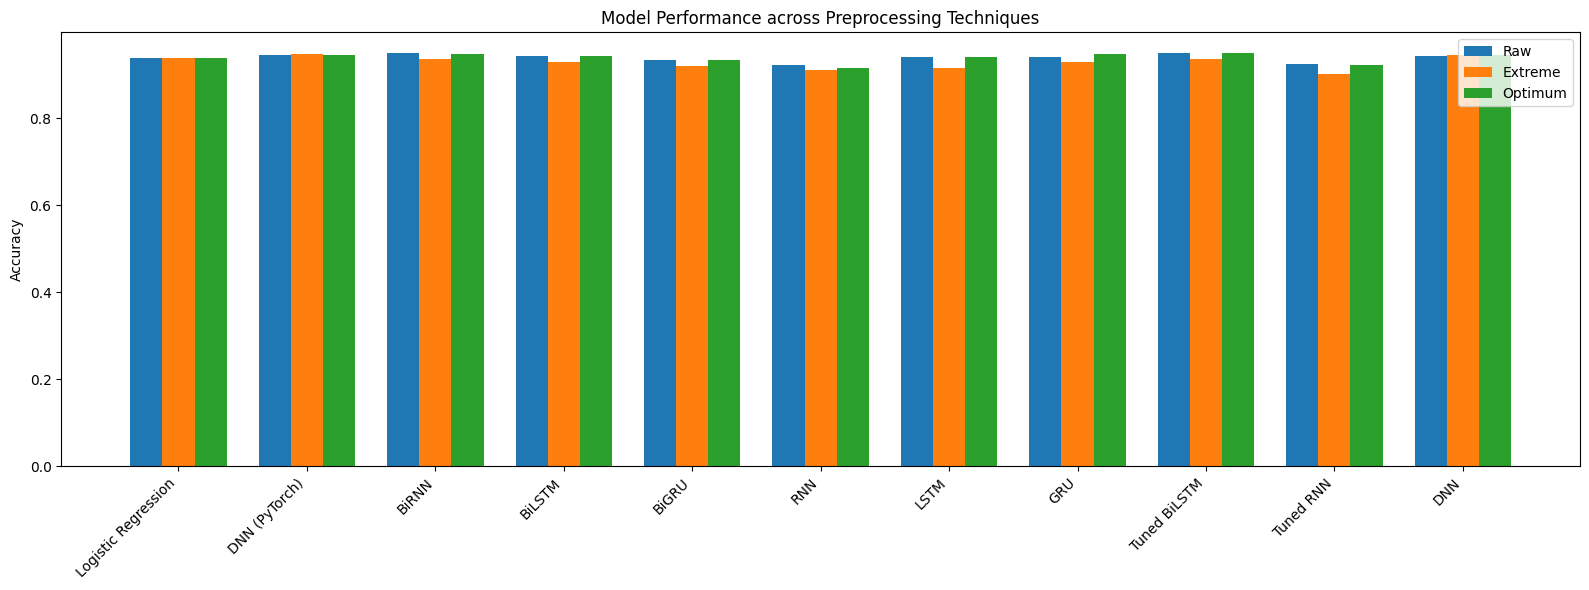

In [88]:
import numpy as np
import matplotlib.pyplot as plt

# Data
dict1 = {
    "Logistic Regression": [0.9384, 0.9378, 0.9382],
    "DNN (PyTorch)": [0.945, 0.9462, 0.9453],
    "BiRNN": [0.9487, 0.9359, 0.9470],
    "BiLSTM": [0.9415, 0.9276, 0.9435],
    "BiGRU": [0.9344, 0.9186, 0.9339],
    "RNN": [0.9217, 0.9096, 0.9150],
    "LSTM": [0.94, 0.916, 0.9404],
    "GRU": [0.9393, 0.9290, 0.9473],
    "Tuned BiLSTM": [0.9487, 0.9348, 0.9494],
    "Tuned RNN": [0.9236, 0.9019, 0.9211],
    "DNN": [0.9436, 0.9458, 0.9452]
}

models = list(dict1.keys())
values = np.array(list(dict1.values()))

raw = values[:, 0]
extreme = values[:, 1]
optimum = values[:, 2]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(16, 6))

# Bars
plt.bar(x - width, raw, width, label='Raw')
plt.bar(x,         extreme, width, label='Extreme')
plt.bar(x + width, optimum, width, label='Optimum')

# Labels
plt.xticks(x, models, rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.title("Model Performance across Preprocessing Techniques")

plt.legend()
plt.tight_layout()
plt.show()